# 2026-09-08 Corrected H$\alpha$ surface density in SF, NSF, and ND regions

## Question

Does the increasing inner **NSF occupancy** reveal emission that was already
present, or is the H$\alpha$ emission itself enhanced/created as galaxies move
through the three infall stages?

This notebook keeps three observables separate in bins of
$\log_{10}\Sigma_\star$ and $R/R_e$:

1. category occupancy $F$;
2. category H$\alpha$ luminosity per total retained usable area $A$; and
3. effective H$\alpha$ brightness within the category $I_{\rm eff}=A/F$.

The exact identity $A=F I_{\rm eff}$ makes the create-versus-reveal comparison
auditable. Galaxies are the independent units; all stage summaries are
galaxy-equal and uncertainty intervals resample whole galaxies.

> **ND is censored.** A Balmer non-detection has no defensible
> Balmer-decrement dust correction. The pipeline all-spaxel map substitutes
> `max(NOISE, raw Halpha flux)` wherever either Balmer line fails. ND curves are
> therefore shown as a **mixed censored proxy**, not as measured corrected
> H$\alpha$, and are excluded from the causal interpretation.


## 1. Configuration and inherited provenance

The sample, geometry, exact SF/NSF/ND masks, and strict finite
`SNR_POSTFIT > 25` retained footprint are inherited from
`20260908_check_combined_SF_fraction_categories_by_stage_SNR_postfit.ipynb`.
The source notebooks remain unchanged.


In [1]:
from __future__ import annotations

import math
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
DATA_ROOT = PROJECT_ROOT / "v3tk_v7.6.8"
CATALOG_PATH = PROJECT_ROOT / "mauve_master_wiki_newclass.fits"
GEOMETRY_PATH = PROJECT_ROOT / "MAUVE_effective_radii.csv"

MASS_FILE_PATTERN = "{galid}_spatial_binning_maps_further.fits"
SFR_FILE_PATTERNS = (
    "{galid}_gas_bin_maps_further.fits",
    "{galid}_gas_BIN_maps_further.fits",
)
EW_FILE_PATTERNS = (
    "{galid}_proxy_EW_maps_further.fits",
    "{galid}_proxy_EW_maps.fits",
)
MASK_FILE_PATTERN = "{galid}_mask.fits"
SFH_FILE_PATTERN = "{galid}_sfh_maps.fits"

MASS_HDU = "LOGMASS_SURFACE_DENSITY"
BIN_HDU_MASS = "BINID"
BIN_HDU_GAS = "BIN_ID"
SFR_HDU = "LOGSFR_SURFACE_DENSITY_HII"
# All-spaxel ordinate only; SFR_HDU remains the original SF-selection map.
ALL_SFR_HDU = "LOGSFR_SURFACE_DENSITY"
EW_HDU = "PROXY_EWHA"
HALPHA_SIGMA_OBS_HDU = "HA6562_SIGMA"
HALPHA_SIGMA_CORR_HDU = "HA6562_SIGMA_CORR"
MASK_TABLE_HDU = "MASKFILE"
MASK_COLUMN = "MASK"
SFH_SNR_POSTFIT_HDU = "SNR_POSTFIT"

EW_HA_MIN = 6.0
HALPHA_SIGMA_MAX = 45.0
SFH_SNR_POSTFIT_MIN = 25.0
I_MAX_PRIMARY = 80.0
MIN_VALID_PIXELS_PER_BIN = 50
MIN_SF_PIXELS_PER_BIN = 20
WCS_TOLERANCE_ARCSEC = 0.05

SIGMA_BIN_WIDTH = 0.25
RADIUS_BIN_WIDTH = 0.25
MASS_CONTOUR_LEVEL = 7.5

mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.grid": False,
})

print(f"Project root: {PROJECT_ROOT}")
print("Scope: corrected Halpha luminosity surface density across SF, NSF, and ND in all three infall stages")
print("No additional inclination correction is applied to either surface-density map.")

# Keep category colours fixed across galaxies; these encode categories, not identity.
BALMER_LINES = ("HB4861", "HA6562")
LINE_LABELS = (r"H$\beta$", r"H$\alpha$")
CATEGORY_COLORS = {"SF": "#2166ac", "ND": "#e69f00", "NSF": "#b2182b"}
REASON_LABELS = (
    "BPT: stable non-HII", "BPT: weak/ambiguous/unavailable", "HII SFR unavailable",
    "EW unavailable", "EW <= 6", "Dispersion unavailable", "Dispersion >= 45",
)
REASON_COLORS = ("#b2182b", "#984ea3", "#999999", "#a6cee3", "#33a02c", "#cab2d6", "#e66101")


N_BOOTSTRAP = 10_000
RANDOM_SEED = 42
MIN_RELIABLE_GALAXIES = 3
MIN_RELIABLE_GALAXY_FRACTION = 0.50
MIN_SF_PIXELS_FOR_SUPPORT = MIN_SF_PIXELS_PER_BIN
STAGE_COLORS = {
    "pre-peak": "#2166ac",
    "close-to-peak": "#1a9850",
    "post-peak": "#d73027",
}
COMPONENT_COLORS = {
    "occupancy": "#2166ac",
    "survivor_intensity": "#e69f00",
    "total_hii": "#111111",
}


import warnings

COLOR_TABLE_PATH = PROJECT_ROOT / "MAUVE_galaxy_colors.dat"
CATEGORY_ORDER = ("SF", "NSF", "ND")
MIN_CATEGORY_PIXELS_PER_BIN = 20
DIAGNOSTIC_MIN_PIXELS_PER_BIN = 20
DIAGNOSTIC_ORDER = ("log_NII_Ha", "log_SII_Ha", "log_OI_Ha", "sigma_Ha")
DIAGNOSTIC_LABELS = {
    "log_NII_Ha": r"$\log_{10}([\mathrm{N\,II}]/\mathrm{H}\alpha)$",
    "log_SII_Ha": r"$\log_{10}(([\mathrm{S\,II}]6716+6731)/\mathrm{H}\alpha)$",
    "log_OI_Ha": r"$\log_{10}([\mathrm{O\,I}]/\mathrm{H}\alpha)$",
    "sigma_Ha": r"$\sigma_{\mathrm{H}\alpha,\mathrm{intr}}$ [km s$^{-1}$]",
}


Project root: /Users/Igniz/Desktop/ICRAR/further
Scope: corrected Halpha luminosity surface density across SF, NSF, and ND in all three infall stages
No additional inclination correction is applied to either surface-density map.


## 2. Exact shared masks and geometry

The inherited partition is

\[
\begin{aligned}
\mathrm{SF} &= \mathrm{valid}\cap\mathrm{finite}(\Sigma_{\rm SFR,HII})
\cap[\mathrm{EW}(\mathrm{H}\alpha)>6\,\AA]
\cap[\sigma_{\mathrm{H}\alpha,\rm intr}<45\,\mathrm{km\,s^{-1}}],\\
\mathrm{ND} &= \mathrm{valid}\cap\neg(\mathrm{H}\alpha\ \mathrm{detected}
\cap\mathrm{H}\beta\ \mathrm{detected}),\\
\mathrm{NSF} &= \mathrm{valid}\cap(\mathrm{H}\alpha\ \mathrm{detected}
\cap\mathrm{H}\beta\ \mathrm{detected})\cap\neg\mathrm{SF}.
\end{aligned}
\]

Detection means raw line `flux/error >= CUT_SN` and `flux >= NOISE`, with the
thresholds read from each gas FITS primary header. These observational
categories are mutually exclusive and exhaustive on the valid disc; NSF is not
a unique physical mechanism.


In [2]:
def normalise_stage_label(value) -> str:
    mapping = {
        1: "pre-peak", 1.0: "pre-peak", "1": "pre-peak",
        2: "close-to-peak", 2.0: "close-to-peak", "2": "close-to-peak",
        3: "post-peak", 3.0: "post-peak", "3": "post-peak",
        "prepeak": "pre-peak", "pre-peak": "pre-peak",
        "close-to-peak": "close-to-peak", "closetopeak": "close-to-peak",
        "near-peak": "close-to-peak", "postpeak": "post-peak", "post-peak": "post-peak",
    }
    key = value if isinstance(value, (int, float)) else str(value).strip().lower().replace(" ", "")
    if key not in mapping:
        raise ValueError(f"Unrecognised RPS/infall stage label: {value!r}")
    return mapping[key]


def first_existing(paths):
    for path in paths:
        for candidate in (path, Path(str(path) + ".gz")):
            if candidate.exists():
                return candidate
    return None


def load_fits_map(path: Path, hdu_name: str, *, return_header: bool = False):
    with fits.open(path, memmap=True) as hdul:
        names = {hdu.name.upper() for hdu in hdul}
        if hdu_name.upper() not in names:
            raise KeyError(f"{path}: missing HDU {hdu_name}; available={sorted(names)}")
        hdu = hdul[hdu_name]
        data = np.asarray(hdu.data, dtype=float).copy()
        header = hdu.header.copy()
    return (data, header) if return_header else data


def load_ngist_mask(path: Path, shape):
    with fits.open(path, memmap=True) as hdul:
        if MASK_TABLE_HDU not in hdul:
            raise KeyError(f"{path}: missing table HDU {MASK_TABLE_HDU}")
        table = hdul[MASK_TABLE_HDU].data
        if MASK_COLUMN not in table.names:
            raise KeyError(f"{path}: missing mask column {MASK_COLUMN}; available={table.names}")
        flat = np.asarray(table[MASK_COLUMN], dtype=int)
    if flat.size != int(np.prod(shape)):
        raise ValueError(f"{path}: mask length {flat.size} cannot reshape to {shape}")
    return flat.reshape(shape)


def celestial_wcs_separation_arcsec(header_a, header_b, shape):
    wa, wb = WCS(header_a).celestial, WCS(header_b).celestial
    if not wa.has_celestial or not wb.has_celestial:
        return np.inf
    ny, nx = shape
    x = np.array([0, nx - 1, 0, nx - 1, (nx - 1) / 2])
    y = np.array([0, 0, ny - 1, ny - 1, (ny - 1) / 2])
    raa, deca = wa.pixel_to_world_values(x, y)
    rab, decb = wb.pixel_to_world_values(x, y)
    cosd = np.cos(np.deg2rad((deca + decb) / 2))
    return float(np.nanmax(np.hypot((raa - rab) * cosd, deca - decb)) * 3600.0)


def tangent_offsets_arcsec(ra_deg, dec_deg, ra0_deg, dec0_deg):
    ra, dec = np.deg2rad(ra_deg), np.deg2rad(dec_deg)
    ra0, dec0 = np.deg2rad(float(ra0_deg)), np.deg2rad(float(dec0_deg))
    dra = (ra - ra0 + np.pi) % (2 * np.pi) - np.pi
    cosc = np.sin(dec0) * np.sin(dec) + np.cos(dec0) * np.cos(dec) * np.cos(dra)
    with np.errstate(divide="ignore", invalid="ignore"):
        east = np.cos(dec) * np.sin(dra) / cosc
        north = (np.cos(dec0) * np.sin(dec) - np.sin(dec0) * np.cos(dec) * np.cos(dra)) / cosc
    return east * 206264.806247, north * 206264.806247


def calculate_deprojected_radius(shape, header, component_rows: pd.DataFrame):
    # Minimum elliptical R/Re over the physical components of one product.
    wcs = WCS(header).celestial
    if not wcs.has_celestial:
        raise ValueError("No celestial WCS available for radius calculation")
    yy, xx = np.indices(shape, dtype=float)
    ra, dec = wcs.pixel_to_world_values(xx, yy)
    radius = np.full(shape, np.inf, dtype=float)
    for _, component in component_rows.iterrows():
        east, north = tangent_offsets_arcsec(
            ra, dec, component.center_ra_deg, component.center_dec_deg
        )
        pa = np.deg2rad(float(component.pa_deg_east_of_north))
        major = east * np.sin(pa) + north * np.cos(pa)
        minor = east * np.cos(pa) - north * np.sin(pa)
        component_radius = np.sqrt(
            (major / float(component.a_re_arcsec)) ** 2
            + (minor / float(component.b_re_arcsec)) ** 2
        )
        radius = np.minimum(radius, component_radius)
    radius[~np.isfinite(radius)] = np.nan
    return radius


def intrinsic_sigma_from_maps(sigma_obs, sigma_corr):
    sigma2 = np.asarray(sigma_obs, dtype=float) ** 2 - np.asarray(sigma_corr, dtype=float) ** 2
    result = np.full(sigma2.shape, np.nan, dtype=float)
    valid = np.isfinite(sigma2) & (sigma2 > 0)
    result[valid] = np.sqrt(sigma2[valid])
    return result


def load_galaxy_maps(row, geometry):
    mass, mass_header = load_fits_map(row.mass_path, MASS_HDU, return_header=True)
    mass_bin = load_fits_map(row.mass_path, BIN_HDU_MASS)
    gas_bin, gas_header = load_fits_map(row.sfr_path, BIN_HDU_GAS, return_header=True)
    sfr = load_fits_map(row.sfr_path, SFR_HDU)
    ew_ha = load_fits_map(row.ew_path, EW_HDU)
    sigma_obs = load_fits_map(row.sfr_path, HALPHA_SIGMA_OBS_HDU)
    sigma_corr = load_fits_map(row.sfr_path, HALPHA_SIGMA_CORR_HDU)
    snr_postfit = load_fits_map(row.sfh_path, SFH_SNR_POSTFIT_HDU)
    shapes = {a.shape for a in (
        mass, mass_bin, gas_bin, sfr, ew_ha, sigma_obs, sigma_corr, snr_postfit
    )}
    if len(shapes) != 1:
        raise ValueError(f"{row.GALID}: map shape mismatch {sorted(shapes)}")
    wcs_sep = celestial_wcs_separation_arcsec(mass_header, gas_header, mass.shape)
    if not np.isfinite(wcs_sep) or wcs_sep > WCS_TOLERANCE_ARCSEC:
        raise ValueError(f"{row.GALID}: mass/gas WCS mismatch {wcs_sep:.4f} arcsec")
    ngist_mask = load_ngist_mask(row.mask_path, mass.shape)
    components = geometry.loc[geometry.notebook_product_id.eq(row.GALID)].copy()
    radius_re = calculate_deprojected_radius(mass.shape, mass_header, components)
    sigma_intrinsic = intrinsic_sigma_from_maps(sigma_obs, sigma_corr)
    valid = (
        np.isfinite(mass) & np.isfinite(gas_bin) & (ngist_mask == 0) & np.isfinite(radius_re)
    )
    sf = (
        valid & np.isfinite(sfr) & np.isfinite(ew_ha) & (ew_ha > EW_HA_MIN)
        & np.isfinite(sigma_intrinsic) & (sigma_intrinsic < HALPHA_SIGMA_MAX)
    )
    maps = {
        "log_sigma_star": mass,
        "log_sigma_sfr": sfr,
        "radius_re": radius_re,
        "snr_postfit": snr_postfit,
        "valid_disc_mask": valid,
        "sf_mask": sf,
        "mass_header": mass_header,
        "wcs_separation_arcsec": wcs_sep,
    }
    return add_detection_categories(maps, row, ew_ha, sigma_intrinsic)


def binned_fraction(values, valid_mask, selected_mask, edges, min_valid=MIN_VALID_PIXELS_PER_BIN):
    rows = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        in_bin = np.isfinite(values) & (values >= lo) & (values < hi)
        n_valid = int((valid_mask & in_bin).sum())
        n_selected = int((selected_mask & in_bin).sum())
        rows.append({
            "center": (lo + hi) / 2,
            "N_valid": n_valid,
            "N_SF": n_selected,
            "f_SF": n_selected / n_valid if n_valid >= min_valid else np.nan,
        })
    return pd.DataFrame(rows)


def radial_mass_trends(maps, edges):
    radius = maps["radius_re"]
    mass = maps["log_sigma_star"]
    rows = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        in_bin = np.isfinite(radius) & (radius >= lo) & (radius < hi)
        all_pixels = maps["valid_disc_mask"] & in_bin
        sf_pixels = maps["sf_mask"] & in_bin
        n_all, n_sf = int(all_pixels.sum()), int(sf_pixels.sum())
        rows.append({
            "radius_center": (lo + hi) / 2,
            "N_all": n_all,
            "N_SF": n_sf,
            "all_median": np.nanmedian(mass[all_pixels]) if n_all >= MIN_VALID_PIXELS_PER_BIN else np.nan,
            "sf_median": np.nanmedian(mass[sf_pixels]) if n_sf >= MIN_SF_PIXELS_PER_BIN else np.nan,
        })
    return pd.DataFrame(rows)

def add_detection_categories(maps, row, ew_ha, sigma_intrinsic):
    """Use Balmer-only ND and preserve the original SF selection exactly."""
    valid, sf = maps["valid_disc_mask"], maps["sf_mask"]
    detected = {}
    invalid_any = np.zeros(valid.shape, dtype=bool)
    with fits.open(row.sfr_path, memmap=True) as hdul:
        header = hdul[0].header
        sn_cut, flux_floor = float(header["CUT_SN"]), float(header["NOISE"])
        if not (np.isfinite(sn_cut) and sn_cut > 0 and np.isfinite(flux_floor) and flux_floor > 0):
            raise ValueError(f"{row.GALID}: invalid detection thresholds")
        if str(header["BPTMODE"]).strip().lower() != "both":
            raise ValueError(f"{row.GALID}: expected the original both-BPT selection")
        for line in BALMER_LINES:
            flux = np.asarray(hdul[line + "_FLUX"].data, dtype=float)
            error = np.asarray(hdul[line + "_FLUX_ERR"].data, dtype=float)
            if flux.shape != valid.shape or error.shape != valid.shape:
                raise ValueError(f"{row.GALID}: {line} shape mismatch")
            measurable = np.isfinite(flux) & np.isfinite(error) & (error > 0)
            invalid_any |= ~measurable
            with np.errstate(divide="ignore", invalid="ignore"):
                detected[line] = measurable & (flux / error >= sn_cut) & (flux >= flux_floor)
        # Do not use the old NII_HA_BPT / SII_HA_BPT ratio HDUs as class maps.
        nii = np.asarray(hdul["NII_BPT"].data).copy()
        sii = np.asarray(hdul["SII_BPT"].data).copy()
        for name, arr in (("NII_BPT", nii), ("SII_BPT", sii)):
            if arr.shape != valid.shape or not np.isin(arr[valid], [-1, 0, 1, 2, 3]).all():
                raise ValueError(f"{row.GALID}: invalid {name} class map")
        provenance = {key: header.get(key, "not recorded")
                      for key in ("CUT_SN", "NOISE", "BPTMODE", "BPTLIMIT", "DUSTLAW")}
    balmer_detected = detected["HA6562"] & detected["HB4861"]
    if np.any(sf & ~balmer_detected):
        raise AssertionError(f"{row.GALID}: original SF includes a Balmer non-detection")
    nd = valid & ~balmer_detected
    nsf = valid & balmer_detected & ~sf
    # Exclusive bookkeeping, in this order: HII gate -> EW gate -> sigma gate.
    # This is a first-failed-gate decomposition, not a unique physical cause.
    has_sfr = np.isfinite(maps["log_sigma_sfr"])
    stable_non_hii = np.isin(nii, [2, 3]) | np.isin(sii, [2, 3])
    both_hii = (nii == 1) & (sii == 1)
    conditions = (
        ~has_sfr & stable_non_hii,
        ~has_sfr & ~both_hii,
        ~has_sfr,
        ~np.isfinite(ew_ha),
        ew_ha <= EW_HA_MIN,
        ~np.isfinite(sigma_intrinsic),
        sigma_intrinsic >= HALPHA_SIGMA_MAX,
    )
    remainder = nsf.copy()
    reasons = {}
    for label, condition in zip(REASON_LABELS, conditions):
        reasons[label] = remainder & condition
        remainder &= ~condition
    if remainder.any():
        raise AssertionError(f"{row.GALID}: unexplained detected non-SF pixels")
    category_sum = sf.astype(np.int8) + nd + nsf
    assert np.array_equal(category_sum, valid.astype(np.int8))
    assert np.array_equal(np.sum(list(reasons.values()), axis=0), nsf.astype(int))
    maps.update({
        "nd_mask": nd, "nsf_mask": nsf, "balmer_detected_mask": balmer_detected,
        "line_detected": detected, "nsf_reasons": reasons,
        "nd_invalid_mask": nd & invalid_any,
        "nd_measured_below_cut_mask": nd & ~invalid_any,
        "detection_provenance": provenance,
    })
    return maps


def binned_categories(values, maps, edges):
    result = binned_fraction(values, maps["valid_disc_mask"], maps["sf_mask"], edges)
    for label, key in (("ND", "nd_mask"), ("NSF", "nsf_mask")):
        extra = binned_fraction(values, maps["valid_disc_mask"], maps[key], edges)
        result["N_" + label] = extra.N_SF
        result["f_" + label] = extra.f_SF
    assert np.array_equal(result.N_SF + result.N_ND + result.N_NSF, result.N_valid)
    shown = result.N_valid >= MIN_VALID_PIXELS_PER_BIN
    assert np.allclose(result.loc[shown, ["f_SF", "f_ND", "f_NSF"]].sum(axis=1), 1)
    assert int(result.N_valid.sum()) == int(maps["valid_disc_mask"].sum())
    return result


def plot_category_fractions(axis, table):
    for label, linestyle in (("SF", "-"), ("ND", "--"), ("NSF", "-.")):
        axis.plot(table.center, table["f_" + label], marker="o", ms=3, lw=1.8,
                  ls=linestyle, color=CATEGORY_COLORS[label], label=r"$f_{\rm " + label + "}$")
    axis.legend(fontsize=8, ncol=3, loc="best")


## 3. Live three-stage sample and product QC

The same primary-sample cut ($i<80^\circ$), combined-system handling, WCS test,
and dynamic product discovery are rerun against the live tree.


In [3]:
def read_master_catalogue(path):
    with fits.open(path) as hdul:
        table = hdul[1].data
        frame = pd.DataFrame({
            "galaxy": [str(value).strip() for value in table["Galaxy"]],
            "logMstar": np.asarray(table["logMstar"], dtype=float),
            "stage_code": np.asarray(table["class"], dtype=float),
        })
    frame["stage"] = frame.stage_code.map(normalise_stage_label)
    return frame


def discover_products(data_root):
    rows = []
    for folder in sorted(path for path in data_root.iterdir()
                         if path.is_dir() and not path.name.endswith("_logs")):
        galid = folder.name
        rows.append({
            "GALID": galid,
            "mass_path": folder / MASS_FILE_PATTERN.format(galid=galid),
            "sfr_path": first_existing([
                folder / pattern.format(galid=galid) for pattern in SFR_FILE_PATTERNS
            ]),
            "ew_path": first_existing([
                folder / pattern.format(galid=galid) for pattern in EW_FILE_PATTERNS
            ]),
            "mask_path": folder / MASK_FILE_PATTERN.format(galid=galid),
            "sfh_path": first_existing([
                folder / SFH_FILE_PATTERN.format(galid=galid)
            ]),
        })
    return pd.DataFrame(rows)


STAGE_ORDER = ("pre-peak", "close-to-peak", "post-peak")
PANEL_ORDER = STAGE_ORDER + ("all stages",)
STAGE_LABELS = {
    "pre-peak": "Pre-peak",
    "close-to-peak": "Close-to-peak",
    "post-peak": "Post-peak",
    "all stages": "All stages",
}

master = read_master_catalogue(CATALOG_PATH)
geometry = pd.read_csv(GEOMETRY_PATH)
required_geometry = {
    "galaxy", "notebook_product_id", "mauve_infall_stage", "center_ra_deg",
    "center_dec_deg", "inclination_deg", "pa_deg_east_of_north",
    "a_re_arcsec", "b_re_arcsec",
}
missing_geometry = required_geometry - set(geometry.columns)
if missing_geometry:
    raise KeyError(f"{GEOMETRY_PATH}: missing columns {sorted(missing_geometry)}")

geometry = geometry.merge(
    master[["galaxy", "logMstar", "stage"]], on="galaxy", how="left",
    validate="one_to_one",
)
geometry["stage_from_geometry"] = geometry.mauve_infall_stage.map(normalise_stage_label)
if not geometry.stage.eq(geometry.stage_from_geometry).all():
    raise RuntimeError("Stage disagreement between the master and effective-radius catalogues")

product_meta = []
for galid, group in geometry.groupby("notebook_product_id", sort=False):
    if group.stage.nunique() != 1:
        raise RuntimeError(f"{galid}: physical components have inconsistent stages")
    product_meta.append({
        "GALID": galid,
        "components": ",".join(group.galaxy),
        "stage": group.stage.iloc[0],
        "inclination": float(group.inclination_deg.max()),
    })

inventory = pd.DataFrame(product_meta).merge(
    discover_products(DATA_ROOT), on="GALID", how="left", validate="one_to_one"
)
candidates = inventory.loc[
    inventory.stage.isin(STAGE_ORDER) & inventory.inclination.lt(I_MAX_PRIMARY)
].sort_values(["stage", "GALID"]).reset_index(drop=True)

# This first pass performs full live QC and records only range/count summaries.
# Maps are not cached so the combined notebook does not retain all galaxies in memory.
qc_rows = []
for row in candidates.itertuples(index=False):
    flags = []
    for label, path in (("mass", row.mass_path), ("sfr", row.sfr_path),
                        ("ew", row.ew_path), ("mask", row.mask_path),
                        ("sfh", row.sfh_path)):
        if not isinstance(path, Path) or not path.exists():
            flags.append(f"missing_{label}_product")
    maps = None
    if not flags:
        try:
            maps = load_galaxy_maps(row, geometry)
            valid = maps["valid_disc_mask"]
            if np.any(maps["sf_mask"] & ~valid):
                flags.append("sf_not_subset_of_valid")
        except Exception as exc:
            flags.append(f"load_error:{type(exc).__name__}:{exc}")
    if maps is not None and not flags:
        valid = maps["valid_disc_mask"]
        category_total = (
            maps["sf_mask"].astype(np.int8)
            + maps["nd_mask"].astype(np.int8)
            + maps["nsf_mask"].astype(np.int8)
        )
        if not np.array_equal(category_total, valid.astype(np.int8)):
            flags.append("category_accounting_failure")
    qc_rows.append({
        "GALID": row.GALID,
        "components": row.components,
        "stage": row.stage,
        "inclination_deg": row.inclination,
        "N_valid": int(valid.sum()) if maps is not None and not flags else 0,
        "N_SF": int(maps["sf_mask"].sum()) if maps is not None and not flags else 0,
        "sigma_min": float(np.nanmin(maps["log_sigma_star"][valid]))
                     if maps is not None and not flags else np.nan,
        "sigma_max": float(np.nanmax(maps["log_sigma_star"][valid]))
                     if maps is not None and not flags else np.nan,
        "radius_min": float(np.nanmin(maps["radius_re"][valid]))
                      if maps is not None and not flags else np.nan,
        "radius_max": float(np.nanmax(maps["radius_re"][valid]))
                      if maps is not None and not flags else np.nan,
        "wcs_separation_arcsec": maps["wcs_separation_arcsec"]
                                if maps is not None and not flags else np.nan,
        "QC_flag": ";".join(flags) if flags else "OK",
    })
    del maps

SAMPLE_QC = pd.DataFrame(qc_rows)
passed_ids = set(SAMPLE_QC.loc[SAMPLE_QC.QC_flag.eq("OK"), "GALID"])
sample = candidates.loc[candidates.GALID.isin(passed_ids)].copy()

display(SAMPLE_QC)
display(SAMPLE_QC.groupby(["stage", "QC_flag"], observed=True).size().rename("N_galaxies"))
for stage in STAGE_ORDER:
    n_pass = int(sample.stage.eq(stage).sum())
    n_candidate = int(candidates.stage.eq(stage).sum())
    print(f"{STAGE_LABELS[stage]}: {n_pass}/{n_candidate} products pass QC")
    if n_pass == 0:
        raise RuntimeError(f"No {stage} galaxies passed the live product QC")
print(f"Total passing products: {len(sample)}/{len(candidates)}")


Pre-peak: 8/8 products pass QC
Close-to-peak: 5/5 products pass QC
Post-peak: 13/16 products pass QC
Total passing products: 26/29


,GALID,components,stage,inclination_deg,N_valid,N_SF,sigma_min,sigma_max,radius_min,radius_max,wcs_separation_arcsec,QC_flag
0,NGC4298,NGC4298,close-to-peak,52.0,498540,144157,6.476232,9.372817,0.002597,2.927309,0.0,OK
1,NGC4424,NGC4424,close-to-peak,61.0,172561,8994,7.113861,9.027295,0.002721,2.533259,0.0,OK
2,NGC4501,NGC4501,close-to-peak,65.0,664236,251936,6.926827,10.916401,0.002436,2.862775,0.0,OK
3,NGC4654,NGC4654,close-to-peak,61.0,659231,345036,6.043689,9.750619,0.000637,2.836630,0.0,OK
4,NGC4694,NGC4694,close-to-peak,62.0,94538,1058,6.934593,9.479634,0.004544,3.796772,0.0,OK
5,IC3392,IC3392,post-peak,68.0,94575,13897,6.969276,9.253759,0.004326,3.084733,0.0,OK
6,NGC4064,NGC4064,post-peak,70.0,179882,3273,6.811374,9.428892,0.002945,1.939061,0.0,OK
7,NGC4293,NGC4293,post-peak,67.0,261523,471,7.243091,10.336573,0.001645,1.842599,0.0,OK
8,NGC4380,NGC4380,post-peak,61.0,502065,64097,6.694095,10.141226,0.001755,2.963534,0.0,OK
9,NGC4394,NGC4394,post-peak,32.0,180654,31915,7.352380,10.783341,0.001999,1.488715,0.0,OK


stage          QC_flag                                                                                             
close-to-peak  OK                                                                                                       5
post-peak      OK                                                                                                      13
               missing_mass_product;missing_sfr_product;missing_ew_product;missing_mask_product;missing_sfh_product     3
pre-peak       OK                                                                                                       8
Name: N_galaxies, dtype: int64

## 4. H$\alpha$ luminosity surface density and diagnostic maps

The pipeline uses

\[
\Sigma_{L(\mathrm{H}\alpha)}
=\frac{\Sigma_{\rm SFR,H\alpha}}{C_{\rm H\alpha}},\qquad
C_{\rm H\alpha}=\mathrm{SFRCOEF},
\]

so that

\[
\log_{10}\Sigma_{L(\mathrm{H}\alpha)}
=\mathrm{LOGSFR\_SURFACE\_DENSITY}-\log_{10}(C_{\rm H\alpha}),
\]

in erg s$^{-1}$ kpc$^{-2}$. This is only a unit conversion: no H$\alpha$
luminosity is interpreted as star formation in NSF. For SF/NSF, both Balmer
lines are detected and the ordinate uses the Calzetti Balmer-decrement
correction. For ND, the same stored all-spaxel ordinate is retained only as the
censored proxy described above.

The supporting line ratios use dust-corrected fluxes but require the raw
pipeline detection threshold for H$\alpha$ and every numerator line; both
[S II] lines must pass. These diagnostics are supplementary because BPT,
EW(H$\alpha$), and H$\alpha$ dispersion participate in the SF/NSF selection.


In [4]:
def read_galaxy_colors(path):
    colors = {}
    for raw in path.read_text().splitlines():
        line = raw.strip()
        if not line or line.startswith("#"):
            continue
        parts = line.split()
        if parts[0].isdigit() or parts[0] == "alias":
            colors[parts[1]] = parts[3]
    return colors


GALAXY_COLORS = read_galaxy_colors(COLOR_TABLE_PATH)


def raw_line_detected(flux, error, cut_sn, noise):
    measurable = np.isfinite(flux) & np.isfinite(error) & (error > 0)
    with np.errstate(divide="ignore", invalid="ignore"):
        return measurable & (flux / error >= cut_sn) & (flux >= noise)


def safe_log_ratio(numerator, denominator, usable):
    result = np.full(np.asarray(numerator).shape, np.nan, dtype=float)
    good = usable & np.isfinite(numerator) & np.isfinite(denominator)
    good &= (numerator > 0) & (denominator > 0)
    with np.errstate(divide="ignore", invalid="ignore"):
        result[good] = np.log10(numerator[good] / denominator[good])
    return result


def load_halpha_category_maps(row, geometry):
    maps = load_galaxy_maps(row, geometry)
    with fits.open(row.sfr_path, memmap=True) as hdul:
        header = hdul[0].header.copy()
        cut_sn = float(header["CUT_SN"])
        noise = float(header["NOISE"])
        sfrcoef = float(header["SFRCOEF"])
        if not (np.isfinite(sfrcoef) and sfrcoef > 0):
            raise ValueError(f"{row.GALID}: invalid SFRCOEF={sfrcoef}")

        def arr(name):
            return np.asarray(hdul[name].data, dtype=float).copy()

        raw = {}
        raw_err = {}
        corrected = {}
        for line in ("HA6562", "HB4861", "NII6583", "SII6716", "SII6730", "OI6300"):
            raw[line] = arr(line + "_FLUX")
            raw_err[line] = arr(line + "_FLUX_ERR")
            corrected[line] = arr(line + "_FLUX_CORR")
        log_sigma_sfr_all = arr("LOGSFR_SURFACE_DENSITY")
        sigma_obs = arr(HALPHA_SIGMA_OBS_HDU)
        sigma_corr = arr(HALPHA_SIGMA_CORR_HDU)
        ew_ha = load_fits_map(row.ew_path, EW_HDU)

        provenance = {
            key: header.get(key, "not recorded")
            for key in (
                "CUT_SN", "NOISE", "DIST_MPC", "DISTREF", "SFRCOEF",
                "SFRIMF", "DUSTLAW", "BPTMODE", "SFRNOTE",
            )
        }

    shapes = {value.shape for value in [
        *raw.values(), *raw_err.values(), *corrected.values(),
        log_sigma_sfr_all, sigma_obs, sigma_corr, ew_ha,
    ]}
    if shapes != {maps["valid_disc_mask"].shape}:
        raise ValueError(f"{row.GALID}: added-map shape mismatch {sorted(shapes)}")

    detected = {
        line: raw_line_detected(raw[line], raw_err[line], cut_sn, noise)
        for line in raw
    }
    if not np.array_equal(detected["HA6562"], maps["line_detected"]["HA6562"]):
        raise AssertionError(f"{row.GALID}: inherited Halpha detection mismatch")
    if not np.array_equal(detected["HB4861"], maps["line_detected"]["HB4861"]):
        raise AssertionError(f"{row.GALID}: inherited Hbeta detection mismatch")

    balmer = detected["HA6562"] & detected["HB4861"]
    nii_ok = balmer & detected["NII6583"]
    sii_ok = balmer & detected["SII6716"] & detected["SII6730"]
    oi_ok = balmer & detected["OI6300"]
    sigma_intrinsic = intrinsic_sigma_from_maps(sigma_obs, sigma_corr)
    log_lha_surface = log_sigma_sfr_all - np.log10(sfrcoef)

    maps.update({
        "log_lha_surface": log_lha_surface,
        "ew_ha": ew_ha,
        "sigma_intrinsic": sigma_intrinsic,
        "diagnostics": {
            "log_NII_Ha": safe_log_ratio(
                corrected["NII6583"], corrected["HA6562"], nii_ok
            ),
            "log_SII_Ha": safe_log_ratio(
                corrected["SII6716"] + corrected["SII6730"],
                corrected["HA6562"], sii_ok,
            ),
            "log_OI_Ha": safe_log_ratio(
                corrected["OI6300"], corrected["HA6562"], oi_ok
            ),
            "sigma_Ha": sigma_intrinsic,
        },
        "diagnostic_valid": {
            "log_NII_Ha": nii_ok,
            "log_SII_Ha": sii_ok,
            "log_OI_Ha": oi_ok,
            "sigma_Ha": np.isfinite(sigma_intrinsic),
        },
        "halpha_provenance": provenance,
        "sfrcoef": sfrcoef,
    })
    measured = maps["sf_mask"] | maps["nsf_mask"]
    if np.any(measured & ~balmer):
        raise AssertionError(f"{row.GALID}: SF/NSF includes a Balmer non-detection")
    if np.any(measured & ~np.isfinite(log_lha_surface)):
        raise AssertionError(f"{row.GALID}: measured category lacks corrected Halpha")
    return maps


print(f"Loaded {len(GALAXY_COLORS)} persisted galaxy colours.")


Loaded 41 persisted galaxy colours.


## 5. Per-galaxy measurements in common bins

For galaxy $g$, bin $b$, and category $c$:

\[
f_{gcb}=\frac{N_{gcb}}{N_{gub}},\qquad
A_{gcb}=\frac{\sum_{i\in(g,c,b)}\Sigma_{L(\mathrm{H}\alpha),i}}
{N_{gub}},\qquad
I_{gcb}=\frac{\sum_{i\in(g,c,b)}\Sigma_{L(\mathrm{H}\alpha),i}}
{N_{gcb}}.
\]

$u$ denotes the strict-S/N retained usable footprint. $A$ is the category's
H$\alpha$ contribution per total usable area; $I$ is its within-category mean.
The stored per-galaxy median of $\log\Sigma_{L(\mathrm{H}\alpha)}$ is an
additional robust check. A usable bin requires 50 pixels; category intensity
support requires 20 category pixels.


In [5]:
def complete_common_edges(minimum, maximum, width, *, lower_limit=None):
    minimum, maximum, width = float(minimum), float(maximum), float(width)
    start = float(lower_limit) if lower_limit is not None else np.floor(minimum / width) * width
    stop = (np.floor(maximum / width) + 1.0) * width
    edges = np.arange(start, stop + 0.5 * width, width)
    if not (edges[0] <= minimum and edges[-1] > maximum):
        raise AssertionError("Common edges do not enclose the live valid range")
    return edges


passing_qc = SAMPLE_QC.loc[SAMPLE_QC.QC_flag.eq("OK")]
COMMON_EDGES = {
    "log_sigma_star": complete_common_edges(
        passing_qc.sigma_min.min(), passing_qc.sigma_max.max(), SIGMA_BIN_WIDTH
    ),
    "radius_re": complete_common_edges(
        passing_qc.radius_min.min(), passing_qc.radius_max.max(),
        RADIUS_BIN_WIDTH, lower_limit=0.0,
    ),
}
VARIABLE_LABELS = {
    "log_sigma_star": r"$\log_{10}(\Sigma_\star/[M_\odot\,\mathrm{kpc}^{-2}])$",
    "radius_re": r"$R/R_e$",
}
MASK_KEYS = {"SF": "sf_mask", "NSF": "nsf_mask", "ND": "nd_mask"}

measurement_rows = []
snr_rows = []
provenance_rows = []
all_retained_strict = True
for galaxy_row in sample.itertuples(index=False):
    maps = load_halpha_category_maps(galaxy_row, geometry)
    original_valid = maps["valid_disc_mask"]
    snr_postfit = maps["snr_postfit"]
    keep = original_valid & np.isfinite(snr_postfit) & (snr_postfit > SFH_SNR_POSTFIT_MIN)
    all_retained_strict &= bool(np.all(snr_postfit[keep] > SFH_SNR_POSTFIT_MIN))
    category_masks = {label: maps[key] & keep for label, key in MASK_KEYS.items()}
    category_total = sum(mask.astype(np.int8) for mask in category_masks.values())
    if not np.array_equal(category_total, keep.astype(np.int8)):
        raise AssertionError(f"{galaxy_row.GALID}: strict-cut category accounting failed")

    snr_rows.append({
        "GALID": galaxy_row.GALID,
        "stage": galaxy_row.stage,
        "N_valid_original": int(original_valid.sum()),
        "N_usable": int(keep.sum()),
        **{f"N_{label}": int(mask.sum()) for label, mask in category_masks.items()},
    })
    provenance_rows.append({"GALID": galaxy_row.GALID, **maps["halpha_provenance"]})

    for variable, edges in COMMON_EDGES.items():
        values = maps[variable]
        for lo, hi in zip(edges[:-1], edges[1:]):
            in_bin = np.isfinite(values) & (values >= lo) & (values < hi)
            usable = keep & in_bin
            n_usable = int(usable.sum())
            eligible_usable = n_usable >= MIN_VALID_PIXELS_PER_BIN
            for category in CATEGORY_ORDER:
                category_mask = category_masks[category] & in_bin
                n_category = int(category_mask.sum())
                linear_lha = np.power(10.0, maps["log_lha_surface"][category_mask])
                if linear_lha.size and (
                    not np.isfinite(linear_lha).all() or np.any(linear_lha <= 0)
                ):
                    raise AssertionError(
                        f"{galaxy_row.GALID} {category}: invalid Halpha surface density"
                    )
                sum_lha = float(linear_lha.sum())
                category_support = bool(
                    eligible_usable and n_category >= MIN_CATEGORY_PIXELS_PER_BIN
                )
                record = {
                    "GALID": galaxy_row.GALID,
                    "stage": galaxy_row.stage,
                    "variable": variable,
                    "bin_left": float(lo),
                    "bin_right": float(hi),
                    "center": float((lo + hi) / 2),
                    "category": category,
                    "is_censored_proxy": category == "ND",
                    "N_usable": n_usable,
                    "N_category": n_category,
                    "eligible_usable": bool(eligible_usable),
                    "category_support": category_support,
                    "f_category": n_category / n_usable if eligible_usable else np.nan,
                    "sum_lha_surface": sum_lha,
                    "lha_per_usable_area": (
                        sum_lha / n_usable if eligible_usable else np.nan
                    ),
                    "lha_mean_within_category": (
                        sum_lha / n_category if n_category > 0 else np.nan
                    ),
                    "median_log_lha_within_category": (
                        float(np.nanmedian(maps["log_lha_surface"][category_mask]))
                        if n_category > 0 else np.nan
                    ),
                }
                for diagnostic in DIAGNOSTIC_ORDER:
                    diagnostic_mask = (
                        category_mask & maps["diagnostic_valid"][diagnostic]
                        & np.isfinite(maps["diagnostics"][diagnostic])
                    )
                    # ND lacks a valid Balmer-decrement correction and is not
                    # used in corrected excitation-ratio comparisons.
                    if category == "ND":
                        diagnostic_mask &= False
                    n_diagnostic = int(diagnostic_mask.sum())
                    record[f"N_{diagnostic}"] = n_diagnostic
                    record[f"median_{diagnostic}"] = (
                        float(np.nanmedian(maps["diagnostics"][diagnostic][diagnostic_mask]))
                        if n_diagnostic > 0 else np.nan
                    )
                measurement_rows.append(record)
    del maps

HALPHA_BY_GALAXY_BIN = pd.DataFrame(measurement_rows)
SNR_SUMMARY = pd.DataFrame(snr_rows)
HALPHA_PROVENANCE = pd.DataFrame(provenance_rows)
STAGE_TOTAL_GALAXIES = {
    stage: int(sample.loc[sample.stage.eq(stage), "GALID"].nunique())
    for stage in STAGE_ORDER
}

assert all_retained_strict
assert set(HALPHA_BY_GALAXY_BIN.GALID) == set(sample.GALID)
assert HALPHA_BY_GALAXY_BIN.groupby(
    ["GALID", "variable", "bin_left"], observed=True
).N_category.sum().equals(
    HALPHA_BY_GALAXY_BIN.groupby(
        ["GALID", "variable", "bin_left"], observed=True
    ).N_usable.first()
)
print("Strict-S/N retained sample by stage")
display(SNR_SUMMARY.groupby("stage").agg(
    N_galaxies=("GALID", "nunique"),
    N_usable=("N_usable", "sum"),
    N_SF=("N_SF", "sum"),
    N_NSF=("N_NSF", "sum"),
    N_ND=("N_ND", "sum"),
).reindex(STAGE_ORDER))


Strict-S/N retained sample by stage


,N_galaxies,N_usable,N_SF,N_NSF,N_ND
stage,,,,,
pre-peak,8,2703316,1420915,929104,353297
close-to-peak,5,1643790,720842,488865,434083
post-peak,13,2825159,222427,815887,1786845


## 6. Equal-galaxy stage estimator and common support

For a stage $s$ with $G_{sb}$ eligible galaxies,

\[
F_{scb}=\frac{1}{G_{sb}}\sum_g f_{gcb},\qquad
A_{scb}=\frac{1}{G_{sb}}\sum_g A_{gcb},\qquad
I_{\mathrm{eff},scb}=\frac{A_{scb}}{F_{scb}}.
\]

Thus $A=F I_{\rm eff}$ exactly. Galaxies with zero pixels in a category retain
$f=A=0$ rather than disappearing. A stage/bin/category is reliable when at
least three galaxies and at least half of the stage have usable support, and at
least three galaxies have 20 or more category pixels. The fiducial range is the
longest contiguous block reliable in every stage, separately for each category
and x-axis.


In [6]:
def stage_halpha_estimator(per_galaxy):
    rows = []
    keys = ["stage", "variable", "bin_left", "bin_right", "center", "category"]
    for group_keys, group in per_galaxy.groupby(keys, observed=True, sort=False):
        rec = dict(zip(keys, group_keys))
        stage = rec["stage"]
        eligible = group.loc[group.eligible_usable].copy()
        supported = eligible.loc[eligible.category_support]
        n_stage = STAGE_TOTAL_GALAXIES[stage]
        rec.update({
            "N_gal_stage": n_stage,
            "N_gal_usable": int(eligible.GALID.nunique()),
            "N_gal_category_support": int(supported.GALID.nunique()),
            "N_spaxel_usable": int(eligible.N_usable.sum()),
            "N_spaxel_category": int(eligible.N_category.sum()),
            "is_censored_proxy": rec["category"] == "ND",
        })
        rec["f_gal_usable"] = rec["N_gal_usable"] / n_stage
        rec["occupancy"] = float(eligible.f_category.mean()) if len(eligible) else np.nan
        rec["lha_per_usable_area"] = (
            float(eligible.lha_per_usable_area.mean()) if len(eligible) else np.nan
        )
        rec["effective_intensity"] = (
            rec["lha_per_usable_area"] / rec["occupancy"]
            if rec["occupancy"] > 0 else np.nan
        )
        rec["typical_median_log_intensity"] = (
            float(supported.median_log_lha_within_category.median())
            if len(supported) else np.nan
        )
        rec["reliable"] = bool(
            rec["N_gal_usable"] >= MIN_RELIABLE_GALAXIES
            and rec["f_gal_usable"] >= MIN_RELIABLE_GALAXY_FRACTION
            and rec["N_gal_category_support"] >= MIN_RELIABLE_GALAXIES
        )
        if rec["occupancy"] > 0:
            if not np.isclose(
                rec["lha_per_usable_area"],
                rec["occupancy"] * rec["effective_intensity"],
                rtol=1e-12, atol=0,
            ):
                raise AssertionError("Stage Halpha decomposition identity failed")
        rows.append(rec)
    return pd.DataFrame(rows)


def largest_contiguous_block(frame):
    frame = frame.sort_values("bin_left").reset_index(drop=True)
    runs = []
    start = stop = None
    n_bins = 0
    for row in frame.itertuples(index=False):
        contiguous = stop is not None and np.isclose(row.bin_left, stop)
        if row.reliable_common and (start is None or contiguous):
            if start is None:
                start = float(row.bin_left)
                n_bins = 0
            stop = float(row.bin_right)
            n_bins += 1
        else:
            if start is not None:
                runs.append((start, stop, n_bins))
            start = float(row.bin_left) if row.reliable_common else None
            stop = float(row.bin_right) if row.reliable_common else None
            n_bins = 1 if row.reliable_common else 0
    if start is not None:
        runs.append((start, stop, n_bins))
    return max(runs, key=lambda item: (item[2], item[1] - item[0])) if runs else (np.nan, np.nan, 0)


STAGE_HALPHA_PROFILES = stage_halpha_estimator(HALPHA_BY_GALAXY_BIN)
common_flags = (
    STAGE_HALPHA_PROFILES.groupby(
        ["category", "variable", "bin_left", "bin_right", "center"], observed=True
    )
    .agg(N_stages=("stage", "nunique"), reliable_common=("reliable", "all"))
    .reset_index()
)
common_flags["reliable_common"] &= common_flags.N_stages.eq(len(STAGE_ORDER))

range_rows = []
COMMON_RELIABLE_RANGES = {}
for category in CATEGORY_ORDER:
    for variable in ("log_sigma_star", "radius_re"):
        block = largest_contiguous_block(common_flags.loc[
            common_flags.category.eq(category) & common_flags.variable.eq(variable)
        ])
        COMMON_RELIABLE_RANGES[(category, variable)] = (block[0], block[1])
        range_rows.append({
            "category": category,
            "variable": variable,
            "fiducial_min": block[0],
            "fiducial_max": block[1],
            "N_contiguous_bins": block[2],
            "measurement_status": "censored proxy" if category == "ND" else "corrected measurement",
        })

COMMON_RELIABLE_RANGE_TABLE = pd.DataFrame(range_rows)
STAGE_HALPHA_PROFILES = STAGE_HALPHA_PROFILES.merge(
    common_flags[[
        "category", "variable", "bin_left", "bin_right", "center", "reliable_common"
    ]],
    on=["category", "variable", "bin_left", "bin_right", "center"],
    how="left", validate="many_to_one",
)
STAGE_HALPHA_PROFILES["in_fiducial_common_range"] = False
for (category, variable), (lo, hi) in COMMON_RELIABLE_RANGES.items():
    use = STAGE_HALPHA_PROFILES.category.eq(category) & STAGE_HALPHA_PROFILES.variable.eq(variable)
    if np.isfinite(lo) and np.isfinite(hi):
        STAGE_HALPHA_PROFILES.loc[use, "in_fiducial_common_range"] = (
            STAGE_HALPHA_PROFILES.loc[use, "center"].ge(lo)
            & STAGE_HALPHA_PROFILES.loc[use, "center"].lt(hi)
        )

display(COMMON_RELIABLE_RANGE_TABLE)


,category,variable,fiducial_min,fiducial_max,N_contiguous_bins,measurement_status
0,SF,log_sigma_star,7.50,9.25,7,corrected measurement
1,SF,radius_re,0.00,2.00,8,corrected measurement
2,NSF,log_sigma_star,7.25,9.25,8,corrected measurement
3,NSF,radius_re,0.00,2.25,9,corrected measurement
4,ND,log_sigma_star,7.25,8.50,5,censored proxy
5,ND,radius_re,0.50,2.25,7,censored proxy


## 7. Whole-galaxy bootstrap and NSF stage contrasts

Each bootstrap draw resamples complete galaxies within one stage, retaining all
their spaxels and bins. The 16th--84th percentile interval is therefore a
between-galaxy uncertainty interval, not a pixel-level error bar.

For NSF and target stage $t$ relative to pre-peak:

\[
\Delta\log A=\log A_t-\log A_{\rm pre},\quad
\Delta\log F=\log F_t-\log F_{\rm pre},\quad
\Delta\log I_{\rm eff}=\log I_{\rm eff,t}-\log I_{\rm eff,pre},
\]

with the exact identity $\Delta\log A=\Delta\log F+\Delta\log I_{\rm eff}$.
Both target and pre-peak galaxies are resampled in the contrast.


In [7]:
def finite_percentiles(values):
    finite = np.asarray(values, dtype=float)
    finite = finite[np.isfinite(finite)]
    return tuple(np.percentile(finite, [16, 84])) if finite.size else (np.nan, np.nan)


def bootstrap_halpha_profiles(per_galaxy, n_boot=N_BOOTSTRAP):
    summary_rows = []
    draws_by_key = {}
    for stage_index, stage in enumerate(STAGE_ORDER):
        stage_galaxies = sample.loc[sample.stage.eq(stage), "GALID"].sort_values().to_numpy()
        for variable_index, variable in enumerate(("log_sigma_star", "radius_re")):
            for category_index, category in enumerate(CATEGORY_ORDER):
                stage_frame = per_galaxy.loc[
                    per_galaxy.stage.eq(stage)
                    & per_galaxy.variable.eq(variable)
                    & per_galaxy.category.eq(category)
                ]
                for bin_index, (lo, hi) in enumerate(zip(
                    COMMON_EDGES[variable][:-1], COMMON_EDGES[variable][1:]
                )):
                    group = stage_frame.loc[np.isclose(stage_frame.bin_left, lo)].set_index("GALID").reindex(stage_galaxies)
                    eligible = group.eligible_usable.fillna(False).to_numpy(bool)
                    supported = group.category_support.fillna(False).to_numpy(bool)
                    f_values = np.where(eligible, group.f_category.to_numpy(float), np.nan)
                    area_values = np.where(eligible, group.lha_per_usable_area.to_numpy(float), np.nan)
                    median_values = np.where(
                        supported,
                        group.median_log_lha_within_category.to_numpy(float),
                        np.nan,
                    )
                    seed = (
                        RANDOM_SEED + 1_000_000 * stage_index
                        + 100_000 * variable_index + 10_000 * category_index + bin_index
                    )
                    rng = np.random.default_rng(seed)
                    indices = rng.integers(0, len(stage_galaxies), size=(n_boot, len(stage_galaxies)))
                    f_sample = f_values[indices]
                    area_sample = area_values[indices]
                    median_sample = median_values[indices]
                    counts = np.isfinite(f_sample).sum(axis=1)
                    f_boot = np.divide(
                        np.nansum(f_sample, axis=1), counts,
                        out=np.full(n_boot, np.nan), where=counts > 0,
                    )
                    area_boot = np.divide(
                        np.nansum(area_sample, axis=1), counts,
                        out=np.full(n_boot, np.nan), where=counts > 0,
                    )
                    intensity_boot = np.divide(
                        area_boot, f_boot, out=np.full(n_boot, np.nan),
                        where=np.isfinite(f_boot) & (f_boot > 0),
                    )
                    with warnings.catch_warnings():
                        warnings.simplefilter("ignore", category=RuntimeWarning)
                        median_boot = np.nanmedian(median_sample, axis=1)
                    key = (stage, variable, category, float(lo))
                    draws_by_key[key] = {
                        "occupancy": f_boot,
                        "lha_per_usable_area": area_boot,
                        "effective_intensity": intensity_boot,
                        "typical_median_log_intensity": median_boot,
                    }
                    central = STAGE_HALPHA_PROFILES.loc[
                        STAGE_HALPHA_PROFILES.stage.eq(stage)
                        & STAGE_HALPHA_PROFILES.variable.eq(variable)
                        & STAGE_HALPHA_PROFILES.category.eq(category)
                        & np.isclose(STAGE_HALPHA_PROFILES.bin_left, lo)
                    ].iloc[0]
                    rec = {
                        "stage": stage, "variable": variable, "category": category,
                        "bin_left": float(lo), "bin_right": float(hi),
                        "center": float((lo + hi) / 2),
                    }
                    for metric, values in draws_by_key[key].items():
                        rec[metric] = float(central[metric])
                        rec[metric + "_lo"], rec[metric + "_hi"] = finite_percentiles(values)
                    summary_rows.append(rec)
    return pd.DataFrame(summary_rows), draws_by_key


HALPHA_BOOTSTRAP, HALPHA_BOOTSTRAP_DRAWS = bootstrap_halpha_profiles(HALPHA_BY_GALAXY_BIN)
HALPHA_BOOTSTRAP = HALPHA_BOOTSTRAP.merge(
    STAGE_HALPHA_PROFILES[[
        "stage", "variable", "category", "bin_left", "bin_right", "center",
        "N_gal_usable", "N_gal_category_support", "reliable", "reliable_common",
        "in_fiducial_common_range", "is_censored_proxy",
    ]],
    on=["stage", "variable", "category", "bin_left", "bin_right", "center"],
    how="left", validate="one_to_one",
)

delta_rows = []
bootstrap_identity_max = 0.0
for target_stage in ("close-to-peak", "post-peak"):
    target_rows = HALPHA_BOOTSTRAP.loc[
        HALPHA_BOOTSTRAP.stage.eq(target_stage) & HALPHA_BOOTSTRAP.category.eq("NSF")
    ]
    for target in target_rows.itertuples(index=False):
        reference = HALPHA_BOOTSTRAP.loc[
            HALPHA_BOOTSTRAP.stage.eq("pre-peak")
            & HALPHA_BOOTSTRAP.variable.eq(target.variable)
            & HALPHA_BOOTSTRAP.category.eq("NSF")
            & np.isclose(HALPHA_BOOTSTRAP.bin_left, target.bin_left)
        ].iloc[0]
        rec = {
            "stage": target_stage,
            "variable": target.variable,
            "bin_left": target.bin_left,
            "bin_right": target.bin_right,
            "center": target.center,
            "reliable_common": bool(target.reliable_common),
            "in_fiducial_common_range": bool(target.in_fiducial_common_range),
        }
        target_draws = HALPHA_BOOTSTRAP_DRAWS[
            (target_stage, target.variable, "NSF", float(target.bin_left))
        ]
        reference_draws = HALPHA_BOOTSTRAP_DRAWS[
            ("pre-peak", target.variable, "NSF", float(target.bin_left))
        ]
        delta_draws = {}
        for metric, short in (
            ("occupancy", "F"),
            ("lha_per_usable_area", "A"),
            ("effective_intensity", "I"),
        ):
            target_value = float(getattr(target, metric))
            reference_value = float(reference[metric])
            rec[f"delta_log_{short}"] = (
                np.log10(target_value) - np.log10(reference_value)
                if target_value > 0 and reference_value > 0 else np.nan
            )
            target_array = target_draws[metric]
            reference_array = reference_draws[metric]
            valid = (
                np.isfinite(target_array) & (target_array > 0)
                & np.isfinite(reference_array) & (reference_array > 0)
            )
            values = np.full(n_boot := len(target_array), np.nan)
            values[valid] = np.log10(target_array[valid]) - np.log10(reference_array[valid])
            delta_draws[short] = values
            rec[f"delta_log_{short}_lo"], rec[f"delta_log_{short}_hi"] = finite_percentiles(values)
        identity = delta_draws["A"] - delta_draws["F"] - delta_draws["I"]
        finite_identity = np.abs(identity[np.isfinite(identity)])
        if finite_identity.size:
            bootstrap_identity_max = max(bootstrap_identity_max, float(finite_identity.max()))
        delta_rows.append(rec)

NSF_STAGE_DECOMPOSITION = pd.DataFrame(delta_rows)
print(f"Bootstrap decomposition max |Delta A - Delta F - Delta I| = {bootstrap_identity_max:.3e} dex")


Bootstrap decomposition max |Delta A - Delta F - Delta I| = 1.399e-14 dex


## 8. Coverage and reliable common ranges

Solid points satisfy the per-stage support rule; vertical dotted lines delimit
the common fiducial block. Counts refer to galaxies with at least 20 pixels in
the category, after the strict S/N cut. ND remains a proxy even where support is
high.


,category,variable,fiducial_min,fiducial_max,N_contiguous_bins,measurement_status
0,SF,log_sigma_star,7.50,9.25,7,corrected measurement
1,SF,radius_re,0.00,2.00,8,corrected measurement
2,NSF,log_sigma_star,7.25,9.25,8,corrected measurement
3,NSF,radius_re,0.00,2.25,9,corrected measurement
4,ND,log_sigma_star,7.25,8.50,5,censored proxy
5,ND,radius_re,0.50,2.25,7,censored proxy


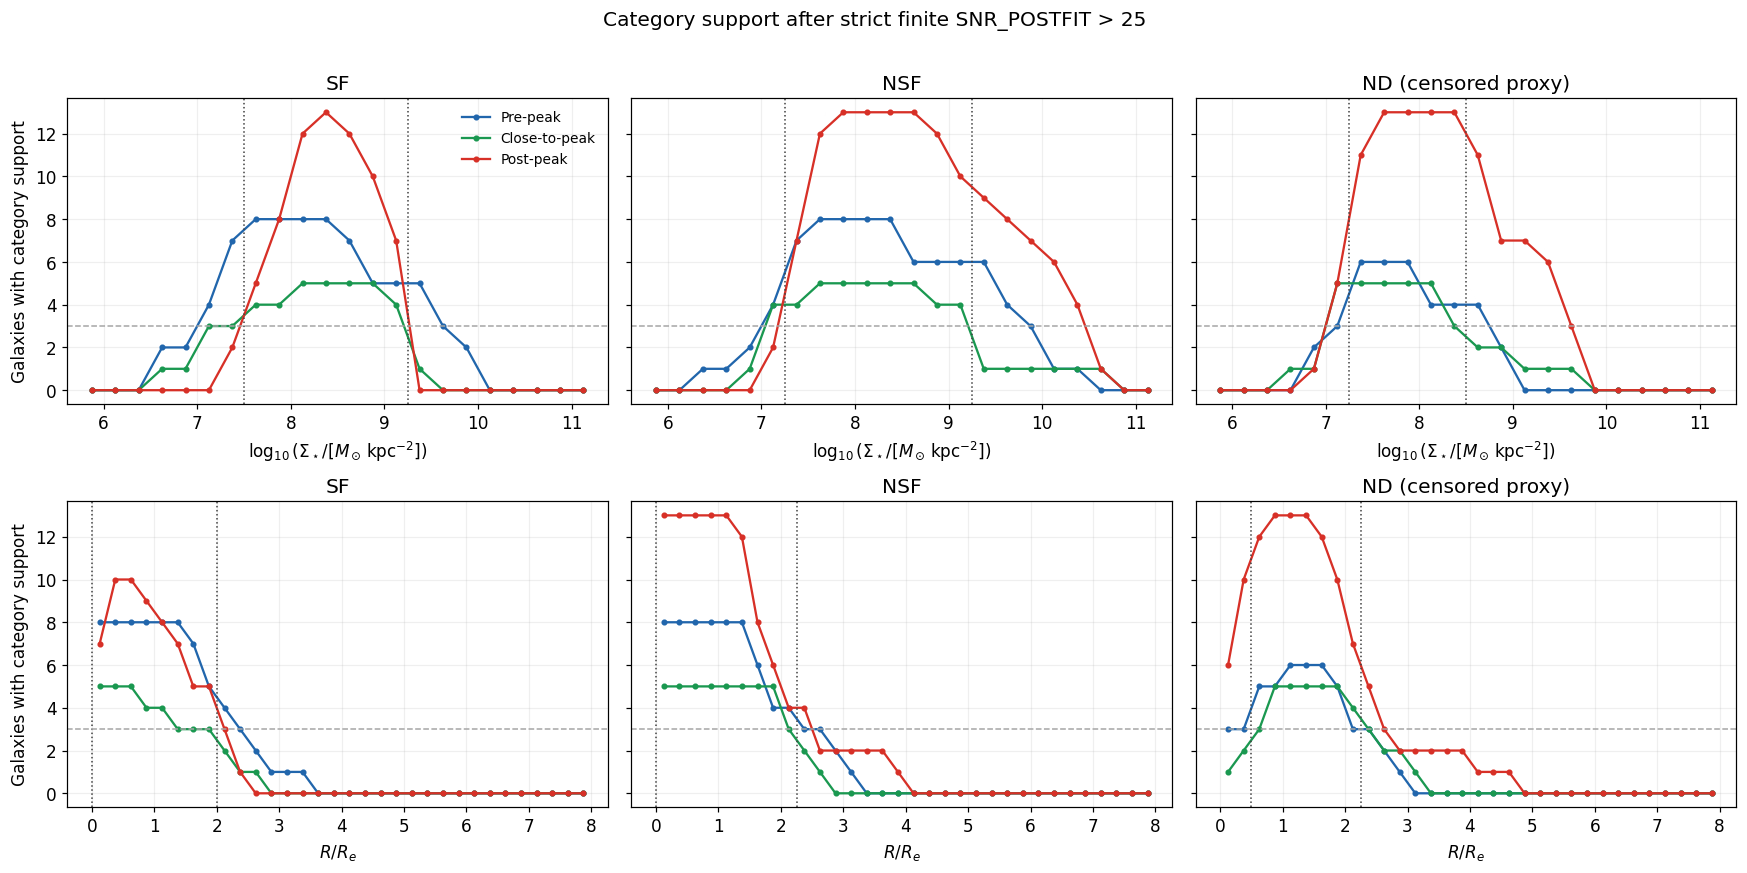

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16.0, 7.8), sharex="row", sharey="row")
for row_index, variable in enumerate(("log_sigma_star", "radius_re")):
    for col_index, category in enumerate(CATEGORY_ORDER):
        ax = axes[row_index, col_index]
        for stage in STAGE_ORDER:
            sub = STAGE_HALPHA_PROFILES.loc[
                STAGE_HALPHA_PROFILES.stage.eq(stage)
                & STAGE_HALPHA_PROFILES.variable.eq(variable)
                & STAGE_HALPHA_PROFILES.category.eq(category)
            ].sort_values("center")
            ax.plot(
                sub.center, sub.N_gal_category_support,
                color=STAGE_COLORS[stage], marker="o", ms=3, lw=1.5,
                label=STAGE_LABELS[stage],
            )
        lo, hi = COMMON_RELIABLE_RANGES[(category, variable)]
        if np.isfinite(lo):
            ax.axvline(lo, color="0.25", ls=":", lw=1)
            ax.axvline(hi, color="0.25", ls=":", lw=1)
        ax.axhline(MIN_RELIABLE_GALAXIES, color="0.65", ls="--", lw=1)
        ax.set_title(category + (" (censored proxy)" if category == "ND" else ""))
        ax.set_xlabel(VARIABLE_LABELS[variable])
        if col_index == 0:
            ax.set_ylabel("Galaxies with category support")
        ax.grid(alpha=0.2)
axes[0, 0].legend(frameon=False, fontsize=9)
fig.suptitle("Category support after strict finite SNR_POSTFIT > 25", y=1.01)
fig.tight_layout()
plt.show()

display(COMMON_RELIABLE_RANGE_TABLE)


## 9. Absolute H$\alpha$ profiles

The first figure shows $\log A$: how much H$\alpha$ luminosity surface density
the category contributes per total retained usable area. The second shows
$\log I_{\rm eff}$: the effective brightness after dividing out the category
occupancy. Curves are equal-galaxy estimates; bands are whole-galaxy 16--84%
intervals. Unsupported points are faint. ND panels are intentionally labelled
as censored proxies.


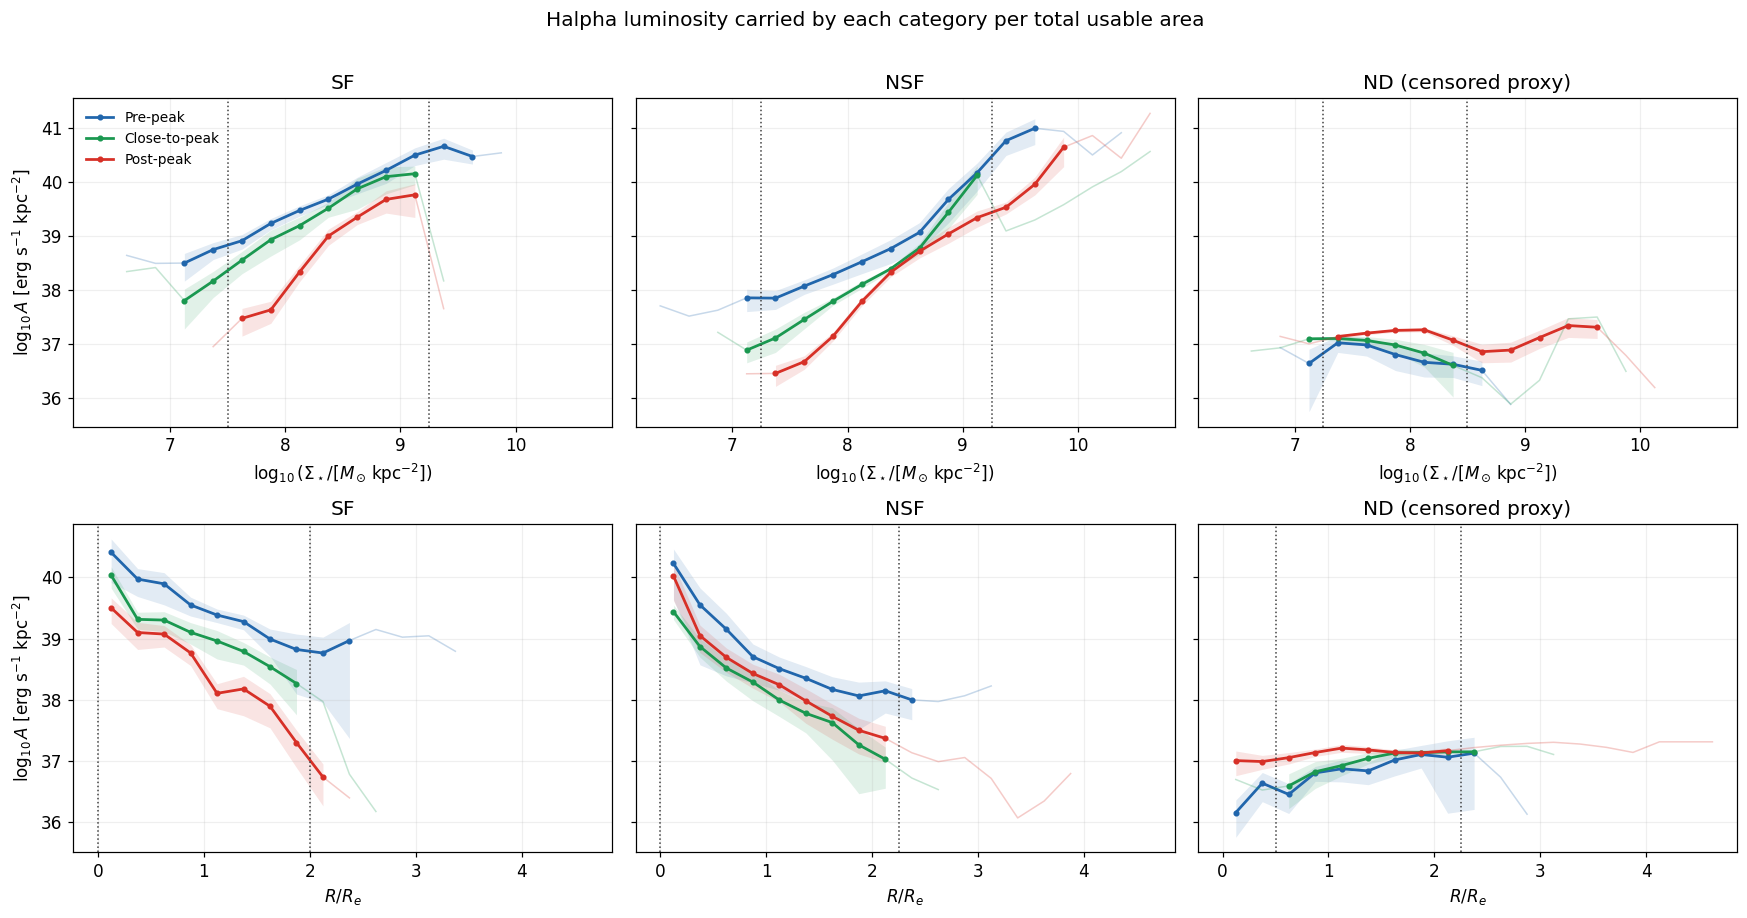

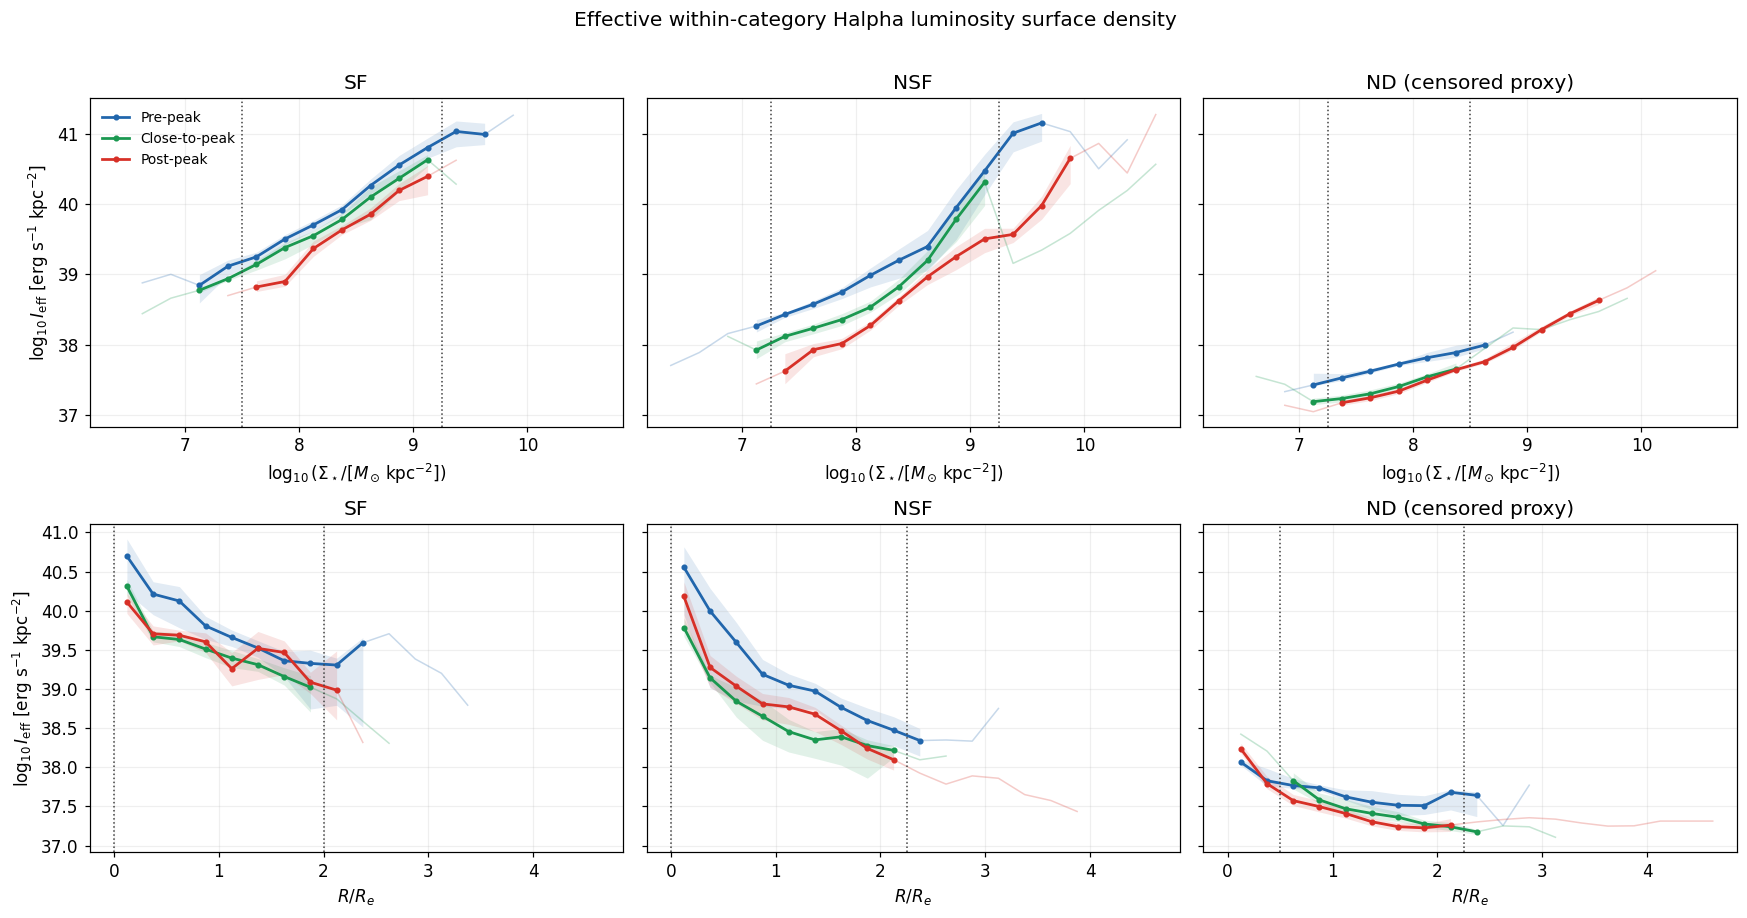

In [9]:
def log_with_interval(frame, metric):
    value = frame[metric].to_numpy(float)
    low = frame[metric + "_lo"].to_numpy(float)
    high = frame[metric + "_hi"].to_numpy(float)
    def positive_log(values):
        result = np.full(values.shape, np.nan)
        good = np.isfinite(values) & (values > 0)
        result[good] = np.log10(values[good])
        return result
    return positive_log(value), positive_log(low), positive_log(high)


def plot_halpha_metric(metric, ylabel, title):
    fig, axes = plt.subplots(2, 3, figsize=(16.0, 8.2), sharex="row", sharey="row")
    for row_index, variable in enumerate(("log_sigma_star", "radius_re")):
        for col_index, category in enumerate(CATEGORY_ORDER):
            ax = axes[row_index, col_index]
            for stage in STAGE_ORDER:
                sub = HALPHA_BOOTSTRAP.loc[
                    HALPHA_BOOTSTRAP.stage.eq(stage)
                    & HALPHA_BOOTSTRAP.variable.eq(variable)
                    & HALPHA_BOOTSTRAP.category.eq(category)
                ].sort_values("center")
                y, ylo, yhi = log_with_interval(sub, metric)
                reliable = sub.reliable.to_numpy(bool)
                ax.plot(sub.center, y, color=STAGE_COLORS[stage], lw=1.0, alpha=0.25)
                ax.plot(
                    sub.center.where(reliable), np.where(reliable, y, np.nan),
                    color=STAGE_COLORS[stage], marker="o", ms=3, lw=1.8,
                    label=STAGE_LABELS[stage],
                )
                ax.fill_between(
                    sub.center, ylo, yhi, where=reliable,
                    color=STAGE_COLORS[stage], alpha=0.13, linewidth=0,
                )
            lo, hi = COMMON_RELIABLE_RANGES[(category, variable)]
            if np.isfinite(lo):
                ax.axvline(lo, color="0.25", ls=":", lw=1)
                ax.axvline(hi, color="0.25", ls=":", lw=1)
            ax.set_title(category + (" (censored proxy)" if category == "ND" else ""))
            ax.set_xlabel(VARIABLE_LABELS[variable])
            if col_index == 0:
                ax.set_ylabel(ylabel)
            ax.grid(alpha=0.2)
    axes[0, 0].legend(frameon=False, fontsize=9)
    fig.suptitle(title, y=1.01)
    fig.tight_layout()
    plt.show()


plot_halpha_metric(
    "lha_per_usable_area",
    r"$\log_{10} A$ [erg s$^{-1}$ kpc$^{-2}$]",
    "Halpha luminosity carried by each category per total usable area",
)
plot_halpha_metric(
    "effective_intensity",
    r"$\log_{10} I_{\rm eff}$ [erg s$^{-1}$ kpc$^{-2}$]",
    "Effective within-category Halpha luminosity surface density",
)


### Reading the absolute profiles

- A changing $A$ alone is ambiguous: it can change because the category covers
  more area ($F$) or because its pixels are brighter ($I_{\rm eff}$).
- $I_{\rm eff}$ is an exact decomposition term, not the median spaxel. The later
  individual-galaxy figure shows the robust median-log intensity separately.
- The ND panels answer only how the pipeline's censored proxy is distributed;
  they cannot establish intrinsic dust-corrected ND luminosity.


## 10. NSF create-versus-reveal decomposition

Only bins in the common reliable NSF range should drive interpretation.

- **Reveal/exposure-like:** $\Delta\log A$ follows $\Delta\log F$ while
  $\Delta\log I_{\rm eff}\simeq0$.
- **Added/enhanced emission:** $\Delta\log I_{\rm eff}>0$ contributes materially
  to $\Delta\log A$, preferably alongside concordant excitation/kinematic
  changes.
- **Dimming plus area change:** $\Delta\log I_{\rm eff}<0$.

These are phenomenological signatures, not unique causal labels.


,stage_minus_pre,variable,N_reliable_bins,median_delta_log_A,median_delta_log_F,median_delta_log_I_eff,N_bins_I_CI_above_zero,N_bins_I_CI_below_zero
0,close-to-peak,log_sigma_star,8,-0.397,-0.083,-0.327,0,5
1,close-to-peak,radius_re,9,-0.633,0.051,-0.592,0,8
2,post-peak,log_sigma_star,8,-0.783,0.018,-0.704,0,8
3,post-peak,radius_re,9,-0.439,0.013,-0.374,0,4


,stage,variable,bin_left,bin_right,delta_log_A,delta_log_A_lo,delta_log_A_hi,delta_log_F,delta_log_F_lo,delta_log_F_hi,delta_log_I,delta_log_I_lo,delta_log_I_hi
6,close-to-peak,log_sigma_star,7.25,7.50,-0.738,-1.027,-0.480,-0.426,-0.662,-0.201,-0.312,-0.393,-0.245
7,close-to-peak,log_sigma_star,7.50,7.75,-0.618,-0.821,-0.425,-0.276,-0.420,-0.128,-0.342,-0.441,-0.259
8,close-to-peak,log_sigma_star,7.75,8.00,-0.495,-0.631,-0.312,-0.103,-0.187,-0.005,-0.392,-0.494,-0.265
9,close-to-peak,log_sigma_star,8.00,8.25,-0.420,-0.577,-0.198,0.033,-0.083,0.137,-0.452,-0.573,-0.264
10,close-to-peak,log_sigma_star,8.25,8.50,-0.374,-0.541,-0.097,0.003,-0.113,0.117,-0.377,-0.549,-0.105
11,close-to-peak,log_sigma_star,8.50,8.75,-0.291,-0.506,0.044,-0.093,-0.271,0.074,-0.198,-0.446,0.161
12,close-to-peak,log_sigma_star,8.75,9.00,-0.239,-0.574,0.192,-0.073,-0.243,0.103,-0.165,-0.546,0.290
13,close-to-peak,log_sigma_star,9.00,9.25,-0.048,-0.420,0.302,0.112,-0.015,0.266,-0.160,-0.551,0.194
60,post-peak,log_sigma_star,7.25,7.50,-1.395,-1.665,-1.136,-0.589,-0.951,-0.328,-0.806,-0.986,-0.552
61,post-peak,log_sigma_star,7.50,7.75,-1.400,-1.581,-1.215,-0.753,-0.895,-0.606,-0.647,-0.756,-0.540


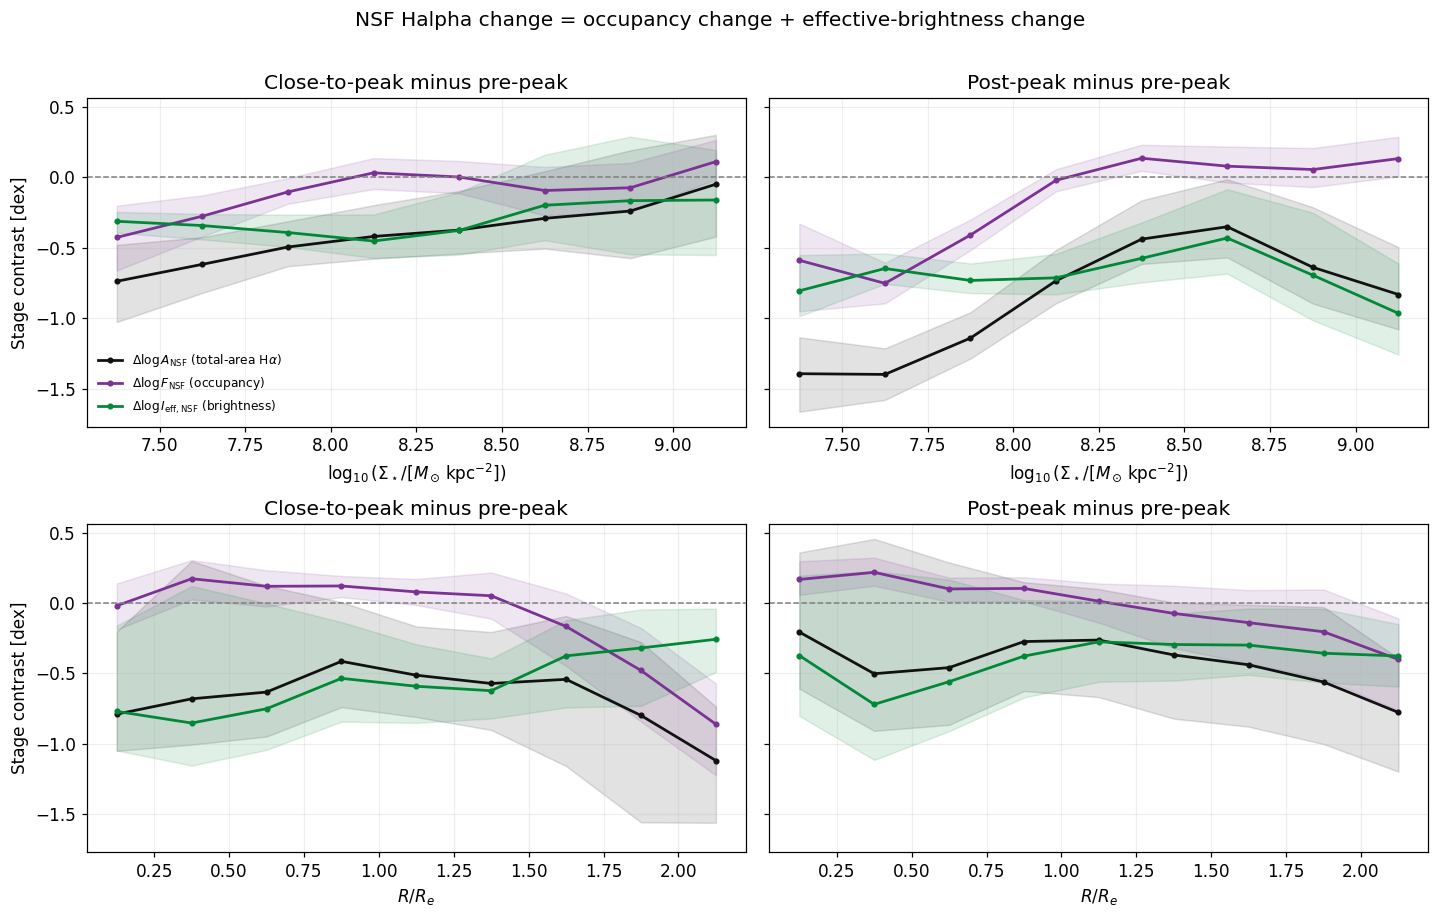

In [10]:
DECOMP_COLORS = {"A": "#111111", "F": "#7b3294", "I": "#008837"}
DECOMP_LABELS = {
    "A": r"$\Delta\log A_{\rm NSF}$ (total-area H$\alpha$)",
    "F": r"$\Delta\log F_{\rm NSF}$ (occupancy)",
    "I": r"$\Delta\log I_{\rm eff,NSF}$ (brightness)",
}

fig, axes = plt.subplots(2, 2, figsize=(13.2, 8.2), sharex="row", sharey=True)
for row_index, variable in enumerate(("log_sigma_star", "radius_re")):
    for col_index, stage in enumerate(("close-to-peak", "post-peak")):
        ax = axes[row_index, col_index]
        sub = NSF_STAGE_DECOMPOSITION.loc[
            NSF_STAGE_DECOMPOSITION.stage.eq(stage)
            & NSF_STAGE_DECOMPOSITION.variable.eq(variable)
            & NSF_STAGE_DECOMPOSITION.in_fiducial_common_range
        ].sort_values("center")
        for short in ("A", "F", "I"):
            y = sub[f"delta_log_{short}"].to_numpy(float)
            ylo = sub[f"delta_log_{short}_lo"].to_numpy(float)
            yhi = sub[f"delta_log_{short}_hi"].to_numpy(float)
            ax.plot(
                sub.center, y, color=DECOMP_COLORS[short], marker="o", ms=3,
                lw=1.8, label=DECOMP_LABELS[short],
            )
            ax.fill_between(sub.center, ylo, yhi, color=DECOMP_COLORS[short], alpha=0.12)
        ax.axhline(0, color="0.5", ls="--", lw=1)
        ax.set_title(f"{STAGE_LABELS[stage]} minus pre-peak")
        ax.set_xlabel(VARIABLE_LABELS[variable])
        if col_index == 0:
            ax.set_ylabel("Stage contrast [dex]")
        ax.grid(alpha=0.2)
axes[0, 0].legend(frameon=False, fontsize=8)
fig.suptitle("NSF Halpha change = occupancy change + effective-brightness change", y=1.01)
fig.tight_layout()
plt.show()

summary_rows = []
for (stage, variable), group in NSF_STAGE_DECOMPOSITION.loc[
    NSF_STAGE_DECOMPOSITION.in_fiducial_common_range
].groupby(["stage", "variable"], observed=True):
    summary_rows.append({
        "stage_minus_pre": stage,
        "variable": variable,
        "N_reliable_bins": len(group),
        "median_delta_log_A": float(group.delta_log_A.median()),
        "median_delta_log_F": float(group.delta_log_F.median()),
        "median_delta_log_I_eff": float(group.delta_log_I.median()),
        "N_bins_I_CI_above_zero": int(group.delta_log_I_lo.gt(0).sum()),
        "N_bins_I_CI_below_zero": int(group.delta_log_I_hi.lt(0).sum()),
    })
DECOMPOSITION_SUMMARY = pd.DataFrame(summary_rows)
display(DECOMPOSITION_SUMMARY.round(3))
display(NSF_STAGE_DECOMPOSITION.loc[
    NSF_STAGE_DECOMPOSITION.in_fiducial_common_range,
    [
        "stage", "variable", "bin_left", "bin_right",
        "delta_log_A", "delta_log_A_lo", "delta_log_A_hi",
        "delta_log_F", "delta_log_F_lo", "delta_log_F_hi",
        "delta_log_I", "delta_log_I_lo", "delta_log_I_hi",
    ],
].sort_values(["variable", "stage", "bin_left"]).round(3))


## 11. Supporting excitation and kinematic contrasts

For each galaxy/bin with at least 20 SF and 20 NSF diagnostic pixels, form

\[
\Delta D_g=\mathrm{median}(D_{\rm NSF})-\mathrm{median}(D_{\rm SF}).
\]

Stage curves are equal-galaxy means and bands are whole-galaxy bootstrap
intervals. Positive line-ratio contrasts mean harder/low-ionisation-sensitive
excitation in NSF relative to SF; positive dispersion contrast means broader
intrinsic H$\alpha$. These are not independent classifiers: the SF/NSF split
already includes BPT, EW, and dispersion gates.


N_bins_with_3_galaxies  N_reliable_bins
diagnostic stage                                                 
log_NII_Ha pre-peak                           21               18
           close-to-peak                      16               16
           post-peak                          16               11
log_SII_Ha pre-peak                           21               18
           close-to-peak                      15               15
           post-peak                          16               11
log_OI_Ha  pre-peak                           17               16
           close-to-peak                      13               13
           post-peak                          11                7
sigma_Ha   pre-peak                           21               18
           close-to-peak                      17               17
           post-peak                          16               11

,diagnostic,stage,variable,N_reliable_bins_in_NSF_range,median_NSF_minus_SF,N_bins_CI_above_zero,N_bins_CI_below_zero
0,log_NII_Ha,close-to-peak,log_sigma_star,8,0.171,8,0
1,log_NII_Ha,close-to-peak,radius_re,7,0.200,7,0
2,log_NII_Ha,post-peak,log_sigma_star,5,0.334,5,0
3,log_NII_Ha,post-peak,radius_re,6,0.298,6,0
4,log_NII_Ha,pre-peak,log_sigma_star,8,0.166,8,0
5,log_NII_Ha,pre-peak,radius_re,9,0.143,9,0
6,log_OI_Ha,close-to-peak,log_sigma_star,7,0.511,7,0
7,log_OI_Ha,close-to-peak,radius_re,6,0.486,6,0
8,log_OI_Ha,post-peak,log_sigma_star,4,0.617,4,0
9,log_OI_Ha,post-peak,radius_re,3,0.669,3,0


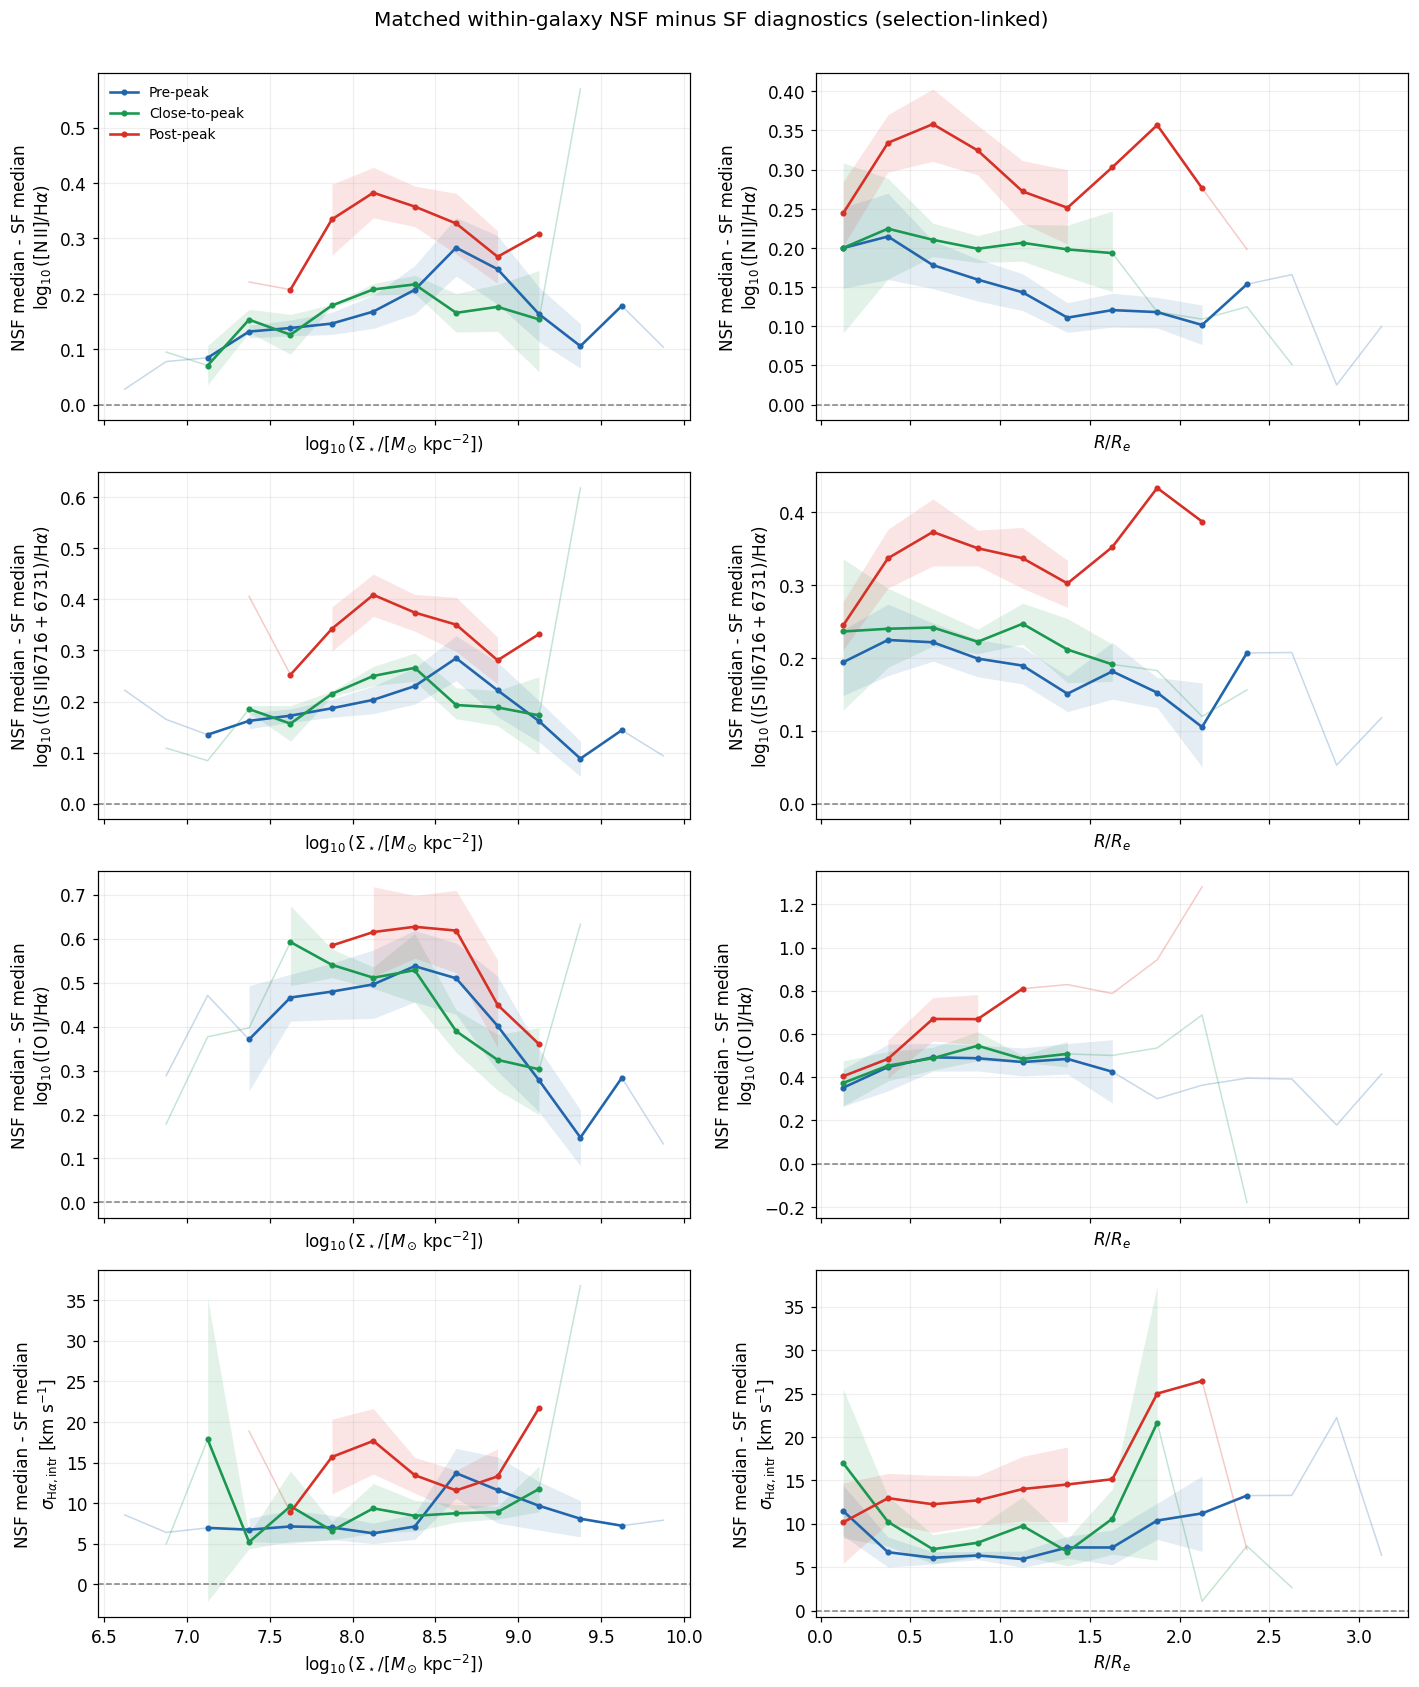

In [11]:
contrast_rows = []
id_columns = ["GALID", "stage", "variable", "bin_left", "bin_right", "center"]
sf_rows = HALPHA_BY_GALAXY_BIN.loc[HALPHA_BY_GALAXY_BIN.category.eq("SF")].set_index(id_columns)
nsf_rows = HALPHA_BY_GALAXY_BIN.loc[HALPHA_BY_GALAXY_BIN.category.eq("NSF")].set_index(id_columns)
for diagnostic in DIAGNOSTIC_ORDER:
    joined = sf_rows[[f"N_{diagnostic}", f"median_{diagnostic}"]].join(
        nsf_rows[[f"N_{diagnostic}", f"median_{diagnostic}"]],
        lsuffix="_SF", rsuffix="_NSF", how="inner", validate="one_to_one",
    ).reset_index()
    supported = (
        joined[f"N_{diagnostic}_SF"].ge(DIAGNOSTIC_MIN_PIXELS_PER_BIN)
        & joined[f"N_{diagnostic}_NSF"].ge(DIAGNOSTIC_MIN_PIXELS_PER_BIN)
    )
    for row in joined.loc[supported].itertuples(index=False):
        contrast_rows.append({
            "GALID": row.GALID,
            "stage": row.stage,
            "variable": row.variable,
            "bin_left": row.bin_left,
            "bin_right": row.bin_right,
            "center": row.center,
            "diagnostic": diagnostic,
            "delta_NSF_minus_SF": (
                getattr(row, f"median_{diagnostic}_NSF")
                - getattr(row, f"median_{diagnostic}_SF")
            ),
        })

DIAGNOSTIC_CONTRAST_BY_GALAXY = pd.DataFrame(contrast_rows)
diag_profile_rows = []
for stage_index, stage in enumerate(STAGE_ORDER):
    stage_galaxies = sample.loc[sample.stage.eq(stage), "GALID"].sort_values().to_numpy()
    for variable_index, variable in enumerate(("log_sigma_star", "radius_re")):
        for diag_index, diagnostic in enumerate(DIAGNOSTIC_ORDER):
            for bin_index, (lo, hi) in enumerate(zip(
                COMMON_EDGES[variable][:-1], COMMON_EDGES[variable][1:]
            )):
                group = DIAGNOSTIC_CONTRAST_BY_GALAXY.loc[
                    DIAGNOSTIC_CONTRAST_BY_GALAXY.stage.eq(stage)
                    & DIAGNOSTIC_CONTRAST_BY_GALAXY.variable.eq(variable)
                    & DIAGNOSTIC_CONTRAST_BY_GALAXY.diagnostic.eq(diagnostic)
                    & np.isclose(DIAGNOSTIC_CONTRAST_BY_GALAXY.bin_left, lo)
                ].set_index("GALID").reindex(stage_galaxies)
                values = group.delta_NSF_minus_SF.to_numpy(float)
                central = float(np.nanmean(values)) if np.isfinite(values).any() else np.nan
                n_support = int(np.isfinite(values).sum())
                seed = (
                    RANDOM_SEED + 4_000_000 + 100_000 * stage_index
                    + 10_000 * variable_index + 1_000 * diag_index + bin_index
                )
                rng = np.random.default_rng(seed)
                indices = rng.integers(0, len(stage_galaxies), size=(N_BOOTSTRAP, len(stage_galaxies)))
                sample_values = values[indices]
                counts = np.isfinite(sample_values).sum(axis=1)
                boot = np.divide(
                    np.nansum(sample_values, axis=1), counts,
                    out=np.full(N_BOOTSTRAP, np.nan), where=counts > 0,
                )
                low, high = finite_percentiles(boot)
                diag_profile_rows.append({
                    "stage": stage, "variable": variable, "diagnostic": diagnostic,
                    "bin_left": float(lo), "bin_right": float(hi),
                    "center": float((lo + hi) / 2),
                    "N_gal_support": n_support,
                    "fraction_stage_support": n_support / len(stage_galaxies),
                    "delta_NSF_minus_SF": central,
                    "delta_lo": low, "delta_hi": high,
                    "reliable": bool(
                        n_support >= MIN_RELIABLE_GALAXIES
                        and n_support / len(stage_galaxies) >= MIN_RELIABLE_GALAXY_FRACTION
                    ),
                })

DIAGNOSTIC_CONTRAST_PROFILES = pd.DataFrame(diag_profile_rows)

fig, axes = plt.subplots(4, 2, figsize=(13.0, 15.2), sharex="col")
for row_index, diagnostic in enumerate(DIAGNOSTIC_ORDER):
    for col_index, variable in enumerate(("log_sigma_star", "radius_re")):
        ax = axes[row_index, col_index]
        for stage in STAGE_ORDER:
            sub = DIAGNOSTIC_CONTRAST_PROFILES.loc[
                DIAGNOSTIC_CONTRAST_PROFILES.stage.eq(stage)
                & DIAGNOSTIC_CONTRAST_PROFILES.variable.eq(variable)
                & DIAGNOSTIC_CONTRAST_PROFILES.diagnostic.eq(diagnostic)
            ].sort_values("center")
            supported = sub.N_gal_support.ge(MIN_RELIABLE_GALAXIES).to_numpy(bool)
            reliable = sub.reliable.to_numpy(bool)
            ax.plot(sub.center, sub.delta_NSF_minus_SF, color=STAGE_COLORS[stage], lw=1, alpha=0.25)
            ax.plot(
                sub.center.where(supported),
                sub.delta_NSF_minus_SF.where(supported),
                color=STAGE_COLORS[stage], marker="o", ms=3, lw=1.7,
                alpha=1.0, label=STAGE_LABELS[stage],
            )
            ax.fill_between(
                sub.center, sub.delta_lo, sub.delta_hi, where=reliable,
                color=STAGE_COLORS[stage], alpha=0.12, linewidth=0,
            )
        ax.axhline(0, color="0.5", ls="--", lw=1)
        ax.set_xlabel(VARIABLE_LABELS[variable])
        ax.set_ylabel("NSF median - SF median\n" + DIAGNOSTIC_LABELS[diagnostic])
        ax.grid(alpha=0.2)
axes[0, 0].legend(frameon=False, fontsize=9)
fig.suptitle("Matched within-galaxy NSF minus SF diagnostics (selection-linked)", y=1.005)
fig.tight_layout()
plt.show()

display(DIAGNOSTIC_CONTRAST_PROFILES.groupby(["diagnostic", "stage"], observed=True).agg(
    N_bins_with_3_galaxies=("N_gal_support", lambda values: int((values >= 3).sum())),
    N_reliable_bins=("reliable", "sum"),
).reindex(pd.MultiIndex.from_product([DIAGNOSTIC_ORDER, STAGE_ORDER], names=["diagnostic", "stage"])))

diagnostic_summary_rows = []
for (diagnostic, stage, variable), group in DIAGNOSTIC_CONTRAST_PROFILES.groupby(
    ["diagnostic", "stage", "variable"], observed=True
):
    lo, hi = COMMON_RELIABLE_RANGES[("NSF", variable)]
    use = group.reliable & group.center.ge(lo) & group.center.lt(hi)
    selected = group.loc[use]
    diagnostic_summary_rows.append({
        "diagnostic": diagnostic,
        "stage": stage,
        "variable": variable,
        "N_reliable_bins_in_NSF_range": len(selected),
        "median_NSF_minus_SF": (
            float(selected.delta_NSF_minus_SF.median()) if len(selected) else np.nan
        ),
        "N_bins_CI_above_zero": int(selected.delta_lo.gt(0).sum()),
        "N_bins_CI_below_zero": int(selected.delta_hi.lt(0).sum()),
    })
DIAGNOSTIC_SUMMARY = pd.DataFrame(diagnostic_summary_rows)
display(DIAGNOSTIC_SUMMARY.round(3))


### Reading the diagnostic contrasts

- A positive NSF--SF contrast confirms that NSF occupies a different
  excitation/kinematic regime, but is partly expected by construction.
- The useful environmental evidence is whether that contrast itself changes
  coherently across stages and at fixed $\Sigma_\star$ or $R/R_e$.
- [O I] is typically the most support-limited diagnostic; do not interpolate
  through bins that fail the displayed galaxy-support rule.
- None of these ratios separates DIG, shocks, AGN, HOLMES, or outflows uniquely.


## 12. Individual-galaxy sensitivity check

Thin curves show each galaxy's median corrected H$\alpha$ intensity using the
fixed project colour table; line style marks stage. Thick curves are the
stage-level median of galaxy medians. This checks whether a stage curve is a
population tendency or a small-number feature. ND remains a censored proxy.


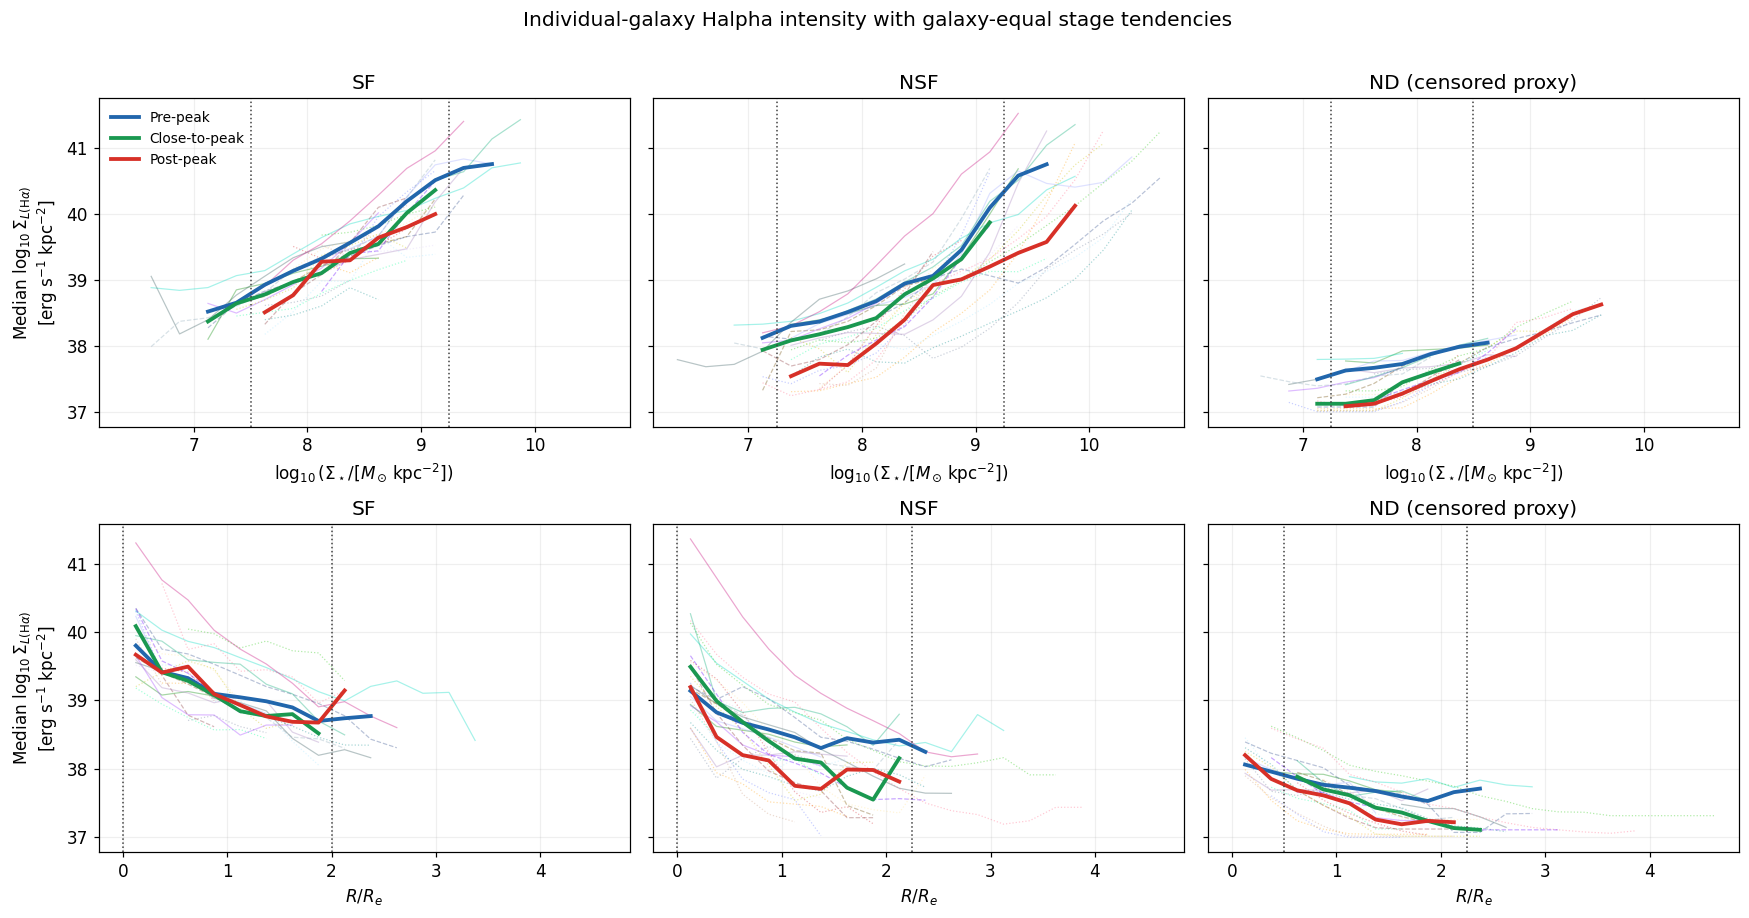

In [12]:
STAGE_LINESTYLES = {"pre-peak": "-", "close-to-peak": "--", "post-peak": ":"}
fig, axes = plt.subplots(2, 3, figsize=(16.0, 8.2), sharex="row", sharey="row")
for row_index, variable in enumerate(("log_sigma_star", "radius_re")):
    for col_index, category in enumerate(CATEGORY_ORDER):
        ax = axes[row_index, col_index]
        individual = HALPHA_BY_GALAXY_BIN.loc[
            HALPHA_BY_GALAXY_BIN.variable.eq(variable)
            & HALPHA_BY_GALAXY_BIN.category.eq(category)
            & HALPHA_BY_GALAXY_BIN.category_support
        ]
        for (galid, stage), group in individual.groupby(["GALID", "stage"], observed=True):
            ax.plot(
                group.center, group.median_log_lha_within_category,
                color=GALAXY_COLORS[galid], ls=STAGE_LINESTYLES[stage],
                lw=0.8, alpha=0.35,
            )
        for stage in STAGE_ORDER:
            stage_profile = HALPHA_BOOTSTRAP.loc[
                HALPHA_BOOTSTRAP.stage.eq(stage)
                & HALPHA_BOOTSTRAP.variable.eq(variable)
                & HALPHA_BOOTSTRAP.category.eq(category)
            ].sort_values("center")
            reliable = stage_profile.reliable.to_numpy(bool)
            ax.plot(
                stage_profile.center.where(reliable),
                stage_profile.typical_median_log_intensity.where(reliable),
                color=STAGE_COLORS[stage], lw=2.5,
                label=STAGE_LABELS[stage],
            )
        lo, hi = COMMON_RELIABLE_RANGES[(category, variable)]
        if np.isfinite(lo):
            ax.axvline(lo, color="0.25", ls=":", lw=1)
            ax.axvline(hi, color="0.25", ls=":", lw=1)
        ax.set_title(category + (" (censored proxy)" if category == "ND" else ""))
        ax.set_xlabel(VARIABLE_LABELS[variable])
        if col_index == 0:
            ax.set_ylabel(r"Median $\log_{10}\Sigma_{L(\mathrm{H}\alpha)}$" + "\n" + r"[erg s$^{-1}$ kpc$^{-2}$]")
        ax.grid(alpha=0.2)
axes[0, 0].legend(frameon=False, fontsize=9)
fig.suptitle("Individual-galaxy Halpha intensity with galaxy-equal stage tendencies", y=1.01)
fig.tight_layout()
plt.show()


## 13. Numerical verification and output-driven synthesis

The checks below validate the live sample, strict cut, category partition,
provenance consistency, exact decomposition, bootstrap centring, finite units,
support ranges, and ND labelling. Passing bookkeeping does not establish a
physical mechanism; the synthesis reports what the measured profiles support.


In [13]:
verification = {}

verification["all_three_stages_present"] = set(sample.stage) == set(STAGE_ORDER)
verification["strict_snr_cut"] = bool(all_retained_strict)
verification["category_accounting"] = bool(
    HALPHA_BY_GALAXY_BIN.groupby(
        ["GALID", "variable", "bin_left"], observed=True
    ).N_category.sum().equals(
        HALPHA_BY_GALAXY_BIN.groupby(
            ["GALID", "variable", "bin_left"], observed=True
        ).N_usable.first()
    )
)
verification["sf_nsf_are_measured"] = bool(
    ~HALPHA_BY_GALAXY_BIN.loc[
        HALPHA_BY_GALAXY_BIN.category.isin(["SF", "NSF"]), "is_censored_proxy"
    ].any()
)
verification["nd_is_always_labelled_proxy"] = bool(
    HALPHA_BY_GALAXY_BIN.loc[
        HALPHA_BY_GALAXY_BIN.category.eq("ND"), "is_censored_proxy"
    ].all()
)
for column in ("CUT_SN", "NOISE", "DIST_MPC", "SFRCOEF", "SFRIMF", "DUSTLAW", "BPTMODE"):
    verification[f"provenance_constant_{column}"] = HALPHA_PROVENANCE[column].nunique(dropna=False) == 1

positive = STAGE_HALPHA_PROFILES.occupancy.gt(0)
verification["stage_decomposition_exact"] = bool(np.allclose(
    STAGE_HALPHA_PROFILES.loc[positive, "lha_per_usable_area"],
    STAGE_HALPHA_PROFILES.loc[positive, "occupancy"]
    * STAGE_HALPHA_PROFILES.loc[positive, "effective_intensity"],
    rtol=1e-12, atol=0,
))
verification["delta_decomposition_exact"] = bool(np.allclose(
    NSF_STAGE_DECOMPOSITION.delta_log_A,
    NSF_STAGE_DECOMPOSITION.delta_log_F + NSF_STAGE_DECOMPOSITION.delta_log_I,
    equal_nan=True, rtol=0, atol=5e-12,
))
verification["bootstrap_delta_decomposition_exact"] = bootstrap_identity_max < 5e-12

central_columns = [
    "stage", "variable", "category", "bin_left",
    "occupancy", "lha_per_usable_area", "effective_intensity",
    "typical_median_log_intensity",
]
central_compare = HALPHA_BOOTSTRAP[central_columns].merge(
    STAGE_HALPHA_PROFILES[central_columns],
    on=["stage", "variable", "category", "bin_left"],
    suffixes=("_boot", "_direct"), validate="one_to_one",
)
for metric in (
    "occupancy", "lha_per_usable_area", "effective_intensity",
    "typical_median_log_intensity",
):
    verification[f"bootstrap_central_matches_{metric}"] = bool(np.allclose(
        central_compare[f"{metric}_boot"], central_compare[f"{metric}_direct"],
        equal_nan=True, rtol=1e-12, atol=0,
    ))

verification["sf_nsf_common_ranges_exist"] = all(
    COMMON_RELIABLE_RANGE_TABLE.loc[
        COMMON_RELIABLE_RANGE_TABLE.category.isin(["SF", "NSF"]),
        "N_contiguous_bins",
    ].gt(0)
)
verification["finite_positive_measured_Halpha"] = bool(
    np.isfinite(HALPHA_BY_GALAXY_BIN.loc[
        HALPHA_BY_GALAXY_BIN.category.isin(["SF", "NSF"])
        & HALPHA_BY_GALAXY_BIN.N_category.gt(0),
        "lha_mean_within_category",
    ]).all()
    and HALPHA_BY_GALAXY_BIN.loc[
        HALPHA_BY_GALAXY_BIN.category.isin(["SF", "NSF"])
        & HALPHA_BY_GALAXY_BIN.N_category.gt(0),
        "lha_mean_within_category",
    ].gt(0).all()
)

VERIFICATION_TABLE = pd.Series(verification, name="passed").to_frame()
display(VERIFICATION_TABLE)
if not VERIFICATION_TABLE.passed.all():
    raise AssertionError("Halpha category verification failed")

display(HALPHA_PROVENANCE.drop(columns=["SFRNOTE"]).drop_duplicates().reset_index(drop=True))
display(COMMON_RELIABLE_RANGE_TABLE)
display(DECOMPOSITION_SUMMARY.round(3))
print("HALPHA_CATEGORY_VERIFICATION_OK")


HALPHA_CATEGORY_VERIFICATION_OK


,passed
all_three_stages_present,True
strict_snr_cut,True
category_accounting,True
sf_nsf_are_measured,True
nd_is_always_labelled_proxy,True
provenance_constant_CUT_SN,True
provenance_constant_NOISE,True
provenance_constant_DIST_MPC,True
provenance_constant_SFRCOEF,True
provenance_constant_SFRIMF,True


,GALID,CUT_SN,NOISE,DIST_MPC,DISTREF,SFRCOEF,SFRIMF,DUSTLAW,BPTMODE
0,NGC4298,3,20,16.5,Fixed MAUVE paper distance scale,4.983582e-42,Chabrier,calzetti,both
1,NGC4424,3,20,16.5,Fixed MAUVE paper distance scale,4.983582e-42,Chabrier,calzetti,both
2,NGC4501,3,20,16.5,Fixed MAUVE paper distance scale,4.983582e-42,Chabrier,calzetti,both
3,NGC4654,3,20,16.5,Fixed MAUVE paper distance scale,4.983582e-42,Chabrier,calzetti,both
4,NGC4694,3,20,16.5,Fixed MAUVE paper distance scale,4.983582e-42,Chabrier,calzetti,both
5,IC3392,3,20,16.5,Fixed MAUVE paper distance scale,4.983582e-42,Chabrier,calzetti,both
6,NGC4064,3,20,16.5,Fixed MAUVE paper distance scale,4.983582e-42,Chabrier,calzetti,both
7,NGC4293,3,20,16.5,Fixed MAUVE paper distance scale,4.983582e-42,Chabrier,calzetti,both
8,NGC4380,3,20,16.5,Fixed MAUVE paper distance scale,4.983582e-42,Chabrier,calzetti,both
9,NGC4394,3,20,16.5,Fixed MAUVE paper distance scale,4.983582e-42,Chabrier,calzetti,both


,category,variable,fiducial_min,fiducial_max,N_contiguous_bins,measurement_status
0,SF,log_sigma_star,7.50,9.25,7,corrected measurement
1,SF,radius_re,0.00,2.00,8,corrected measurement
2,NSF,log_sigma_star,7.25,9.25,8,corrected measurement
3,NSF,radius_re,0.00,2.25,9,corrected measurement
4,ND,log_sigma_star,7.25,8.50,5,censored proxy
5,ND,radius_re,0.50,2.25,7,censored proxy


,stage_minus_pre,variable,N_reliable_bins,median_delta_log_A,median_delta_log_F,median_delta_log_I_eff,N_bins_I_CI_above_zero,N_bins_I_CI_below_zero
0,close-to-peak,log_sigma_star,8,-0.397,-0.083,-0.327,0,5
1,close-to-peak,radius_re,9,-0.633,0.051,-0.592,0,8
2,post-peak,log_sigma_star,8,-0.783,0.018,-0.704,0,8
3,post-peak,radius_re,9,-0.439,0.013,-0.374,0,4


In [14]:
from IPython.display import Markdown


def axis_name(variable):
    return "log stellar-mass surface density" if variable == "log_sigma_star" else "R/Re"


lines = [
    "## Reading the measured result",
    "",
    "The reliable-bin NSF decomposition is the central result:",
    "",
]
for row in DECOMPOSITION_SUMMARY.itertuples(index=False):
    stage_label = STAGE_LABELS[row.stage_minus_pre]
    lines.append(
        f"- **{stage_label} minus pre-peak along {axis_name(row.variable)}:** "
        f"median across {row.N_reliable_bins} reliable bins "
        f"$\\Delta\\log A={row.median_delta_log_A:+.2f}$ dex, "
        f"$\\Delta\\log F={row.median_delta_log_F:+.2f}$ dex, and "
        f"$\\Delta\\log I_{{\\rm eff}}={row.median_delta_log_I_eff:+.2f}$ dex. "
        f"The per-bin bootstrap interval for $\\Delta\\log I_{{\\rm eff}}$ is "
        f"entirely above zero in {row.N_bins_I_CI_above_zero} bins and entirely "
        f"below zero in {row.N_bins_I_CI_below_zero} bins."
    )

lines.extend([
    "",
    "Interpretation must follow the plotted bin-by-bin intervals, not only these medians. "
    "A near-zero effective-brightness term with a changing occupancy term supports a "
    "reveal/redistribution-dominated description; a coherently positive brightness term "
    "supports added/enhanced Halpha emission. The diagnostic contrasts can strengthen "
    "that phenomenology but cannot identify DIG, shocks, AGN, HOLMES, or outflows uniquely.",
    "",
    "ND is not part of that inference: its displayed Halpha quantity is the pipeline's "
    "mixed raw-flux/floor censored proxy, because a Balmer decrement cannot be measured "
    "when either Balmer line is undetected.",
])

lines.extend([
    "",
    "### Supporting diagnostic pattern",
    "",
])
for diagnostic in DIAGNOSTIC_ORDER:
    for variable in ("log_sigma_star", "radius_re"):
        sub = DIAGNOSTIC_SUMMARY.loc[
            DIAGNOSTIC_SUMMARY.diagnostic.eq(diagnostic)
            & DIAGNOSTIC_SUMMARY.variable.eq(variable)
        ].set_index("stage").reindex(STAGE_ORDER)
        values = ", ".join(
            f"{STAGE_LABELS[stage]} {sub.loc[stage, 'median_NSF_minus_SF']:+.2f}"
            for stage in STAGE_ORDER
            if np.isfinite(sub.loc[stage, "median_NSF_minus_SF"])
        )
        lines.append(
            f"- Along {axis_name(variable)}, the median reliable-bin NSF-SF "
            f"contrast in {DIAGNOSTIC_LABELS[diagnostic]} is: {values}."
        )
lines.extend([
    "",
    "These positive NSF-SF excitation/dispersion offsets show that the categories "
    "differ observationally; the generally larger post-peak low-ionisation-line "
    "offsets are supplementary evidence only because the category definition is "
    "selection-linked and the ratios do not identify a unique ionisation source.",
])
display(Markdown("\n".join(lines)))


## Reading the measured result

The reliable-bin NSF decomposition is the central result:

- **Close-to-peak minus pre-peak along log stellar-mass surface density:** median across 8 reliable bins $\Delta\log A=-0.40$ dex, $\Delta\log F=-0.08$ dex, and $\Delta\log I_{\rm eff}=-0.33$ dex. The per-bin bootstrap interval for $\Delta\log I_{\rm eff}$ is entirely above zero in 0 bins and entirely below zero in 5 bins.
- **Close-to-peak minus pre-peak along R/Re:** median across 9 reliable bins $\Delta\log A=-0.63$ dex, $\Delta\log F=+0.05$ dex, and $\Delta\log I_{\rm eff}=-0.59$ dex. The per-bin bootstrap interval for $\Delta\log I_{\rm eff}$ is entirely above zero in 0 bins and entirely below zero in 8 bins.
- **Post-peak minus pre-peak along log stellar-mass surface density:** median across 8 reliable bins $\Delta\log A=-0.78$ dex, $\Delta\log F=+0.02$ dex, and $\Delta\log I_{\rm eff}=-0.70$ dex. The per-bin bootstrap interval for $\Delta\log I_{\rm eff}$ is entirely above zero in 0 bins and entirely below zero in 8 bins.
- **Post-peak minus pre-peak along R/Re:** median across 9 reliable bins $\Delta\log A=-0.44$ dex, $\Delta\log F=+0.01$ dex, and $\Delta\log I_{\rm eff}=-0.37$ dex. The per-bin bootstrap interval for $\Delta\log I_{\rm eff}$ is entirely above zero in 0 bins and entirely below zero in 4 bins.

Interpretation must follow the plotted bin-by-bin intervals, not only these medians. A near-zero effective-brightness term with a changing occupancy term supports a reveal/redistribution-dominated description; a coherently positive brightness term supports added/enhanced Halpha emission. The diagnostic contrasts can strengthen that phenomenology but cannot identify DIG, shocks, AGN, HOLMES, or outflows uniquely.

ND is not part of that inference: its displayed Halpha quantity is the pipeline's mixed raw-flux/floor censored proxy, because a Balmer decrement cannot be measured when either Balmer line is undetected.

### Supporting diagnostic pattern

- Along log stellar-mass surface density, the median reliable-bin NSF-SF contrast in $\log_{10}([\mathrm{N\,II}]/\mathrm{H}\alpha)$ is: Pre-peak +0.17, Close-to-peak +0.17, Post-peak +0.33.
- Along R/Re, the median reliable-bin NSF-SF contrast in $\log_{10}([\mathrm{N\,II}]/\mathrm{H}\alpha)$ is: Pre-peak +0.14, Close-to-peak +0.20, Post-peak +0.30.
- Along log stellar-mass surface density, the median reliable-bin NSF-SF contrast in $\log_{10}(([\mathrm{S\,II}]6716+6731)/\mathrm{H}\alpha)$ is: Pre-peak +0.20, Close-to-peak +0.19, Post-peak +0.35.
- Along R/Re, the median reliable-bin NSF-SF contrast in $\log_{10}(([\mathrm{S\,II}]6716+6731)/\mathrm{H}\alpha)$ is: Pre-peak +0.19, Close-to-peak +0.24, Post-peak +0.34.
- Along log stellar-mass surface density, the median reliable-bin NSF-SF contrast in $\log_{10}([\mathrm{O\,I}]/\mathrm{H}\alpha)$ is: Pre-peak +0.47, Close-to-peak +0.51, Post-peak +0.62.
- Along R/Re, the median reliable-bin NSF-SF contrast in $\log_{10}([\mathrm{O\,I}]/\mathrm{H}\alpha)$ is: Pre-peak +0.47, Close-to-peak +0.49, Post-peak +0.67.
- Along log stellar-mass surface density, the median reliable-bin NSF-SF contrast in $\sigma_{\mathrm{H}\alpha,\mathrm{intr}}$ [km s$^{-1}$] is: Pre-peak +7.12, Close-to-peak +8.82, Post-peak +13.44.
- Along R/Re, the median reliable-bin NSF-SF contrast in $\sigma_{\mathrm{H}\alpha,\mathrm{intr}}$ [km s$^{-1}$] is: Pre-peak +7.26, Close-to-peak +9.98, Post-peak +12.82.

These positive NSF-SF excitation/dispersion offsets show that the categories differ observationally; the generally larger post-peak low-ionisation-line offsets are supplementary evidence only because the category definition is selection-linked and the ratios do not identify a unique ionisation source.